# Sleep Disorder Risk Classification — Assignment 2: Neural Networks (MLP)

**Author:** Gavrila Robert Daniel  
**Dataset:** Sleep Health and Daily Performance Dataset (Kaggle, 100 000 records, 32 features)  
**Task:** Predict **sleep disorder risk** level: Healthy / Mild / Moderate / Severe  
**Model:** Multi-Layer Perceptron (MLP) classifier  

> This notebook is a direct continuation of Assignment 1, which used Decision Trees, Random Forest, and Naive Bayes.  
> All preprocessing, feature engineering, and dataset choices are kept **identical** to A1 to ensure a fair comparison.

---

## Table of Contents
1. [Dataset Description](#1-dataset-description)
2. [Data Loading & Initial Exploration](#2-data-loading--initial-exploration)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Preprocessing — Scaling & Encoding](#4-preprocessing)
5. [Train/Test Split with Stratification](#5-traintest-split-with-stratification)
6. [Performance Metrics](#6-performance-metrics)
7. [Feature Selection (Slim Models)](#7-feature-selection-slim-models)
8. [Model Building, Evaluation & Optimisation (MLP)](#8-model-building-evaluation--optimisation-mlp)
9. [Feature Engineering & Re-evaluation](#9-feature-engineering--re-evaluation)
10. [Comparison: A1 vs A2 Models](#10-comparison-a1-vs-a2-models)
11. [Final Conclusions](#11-final-conclusions)

---

## 1. Dataset Description

### 1.1 Source
Kaggle: https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset  
The CSV is loaded directly from the same directory as this notebook (`sleep_health.csv`), or downloaded automatically via the Kaggle CLI.

### 1.2 Problem Context
Poor sleep quality is a growing public-health concern linked to cardiovascular disease, obesity, impaired cognition, and mental health disorders. This dataset captures a wide range of lifestyle, physiological, and environmental variables for **100 000 individuals** and labels each with a sleep disorder risk level. The goal is to build a classifier that can predict this risk automatically.

**Classification target:** `sleep_disorder_risk`

| Class | Meaning | Approx. share |
|-------|---------|---------------|
| `Healthy` | No significant risk | 54 % |
| `Mild` | Mild risk indicators | 33 % |
| `Moderate` | Clinically relevant risk | 8 % |
| `Severe` | High risk — intervention recommended | 4 % |

### 1.3 Feature Description (31 predictors after dropping `person_id`)

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | `age` | Integer (18–69) | Age of the individual |
| 2 | `gender` | Nominal | Female / Male / Other |
| 3 | `occupation` | Nominal | Job type (12 categories) |
| 4 | `bmi` | Float (16–45) | Body Mass Index |
| 5 | `country` | Nominal | Country of residence (15 countries) |
| 6 | `sleep_duration_hrs` | Float (3–10.5) | Average nightly sleep in hours |
| 7 | `sleep_quality_score` | Float (1–10) | Self-reported sleep quality |
| 8 | `rem_percentage` | Float (10–30) | % of sleep in REM stage |
| 9 | `deep_sleep_percentage` | Float (5–30) | % of sleep in deep/slow-wave stage |
| 10 | `sleep_latency_mins` | Integer (1–58) | Minutes to fall asleep |
| 11 | `wake_episodes_per_night` | Integer (0–8) | Number of wake-ups per night |
| 12 | `caffeine_mg_before_bed` | Integer (0–400) | mg of caffeine consumed before bed |
| 13 | `alcohol_units_before_bed` | Float (0–6) | Alcohol units consumed before bed |
| 14 | `screen_time_before_bed_mins` | Integer (2–180) | Minutes of screen use before bed |
| 15 | `exercise_day` | Binary (0/1) | Whether the person exercised that day |
| 16 | `steps_that_day` | Integer (500–20 000) | Step count for the day |
| 17 | `nap_duration_mins` | Integer (0–116) | Duration of daytime nap in minutes |
| 18 | `stress_score` | Float (1–10) | Self-reported stress level |
| 19 | `work_hours_that_day` | Float (0–18) | Working hours that day |
| 20 | `chronotype` | Nominal | Morning / Neutral / Evening person |
| 21 | `mental_health_condition` | Nominal | Healthy / Anxiety / Depression / Both |
| 22 | `heart_rate_resting_bpm` | Integer (45–99) | Resting heart rate |
| 23 | `sleep_aid_used` | Binary (0/1) | Whether a sleep aid was used |
| 24 | `shift_work` | Binary (0/1) | Whether person does shift work |
| 25 | `room_temperature_celsius` | Float (15–28) | Bedroom temperature |
| 26 | `weekend_sleep_diff_hrs` | Float (−1 to 3) | Extra sleep on weekends (social jetlag) |
| 27 | `season` | Nominal | Season at time of recording |
| 28 | `day_type` | Nominal | Weekday / Weekend |
| 29 | `cognitive_performance_score` | Float (0–100) | Score on a cognitive test |
| 30 | `felt_rested` | Binary (0/1) | Whether person felt rested on waking |
| 31 | `sleep_disorder_risk` | Nominal | **Target variable** |

### 1.4 Summary Statistics
- **100 000 instances**, **31 features** (after ID drop)
- **No missing values** (confirmed in Section 2)
- **Imbalanced target** (54 % Healthy) → stratified split + macro-F1 metric

---

## 2. Data Loading & Initial Exploration

In [8]:
%pip install -q scikit-learn pandas numpy matplotlib seaborn scipy
print("All dependencies ready.")

Note: you may need to restart the kernel to use updated packages.
All dependencies ready.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os, warnings, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
sns.set_palette("Set2")
SEED = 42
np.random.seed(SEED)

CSV_PATH = Path("sleep_health.csv")

if not CSV_PATH.exists():
    try:
        result = subprocess.run(
            ["kaggle", "datasets", "download", "-d",
             "mohankrishnathalla/sleep-health-and-daily-performance-dataset",
             "--unzip"],
            capture_output=True, encoding="utf-8", errors="replace"
        )
        csvs = list(Path(".").glob("*.csv"))
        if csvs:
            csvs[0].rename(CSV_PATH)
        print("Downloaded via Kaggle CLI.")
    except Exception as e:
        print(f"Kaggle CLI unavailable ({e}). Trying public mirror…")
        import urllib.request
        mirrors = [
            "https://raw.githubusercontent.com/dsrscientist/dataset1/master/sleep_health_and_lifestyle_dataset.csv",
            "https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Sleep%20Health%20and%20Lifestyle%20Dataset.csv",
        ]
        for url in mirrors:
            try:
                urllib.request.urlretrieve(url, CSV_PATH)
                print(f"Downloaded from: {url}"); break
            except Exception as ex:
                print(f"  mirror failed: {ex}")
        else:
            raise RuntimeError(
                "Could not download dataset automatically. "
                "Please place sleep_health.csv in the same directory as this notebook.")

df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded dataset — shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded dataset — shape: 100,000 rows × 32 columns


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0


In [10]:
print("=== Data Types ===")
print(df_raw.dtypes.to_string())
print(f"\n=== Missing Values (total: {df_raw.isnull().sum().sum()}) ===")
print(df_raw.isnull().sum().to_string())

=== Data Types ===
person_id                        int64
age                              int64
gender                             str
occupation                         str
bmi                            float64
country                            str
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                         str
mental_health_condition            str
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift_work                       int64
room_t

In [11]:
vc = df_raw["sleep_disorder_risk"].value_counts()
pct = (vc / len(df_raw) * 100).round(1)
print(pd.DataFrame({"Count": vc, "Pct %": pct}).to_string())

                     Count  Pct %
sleep_disorder_risk              
Healthy              54156   54.2
Mild                 33479   33.5
Moderate              8299    8.3
Severe                4066    4.1


In [12]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.50,28867.66,1.0,25000.75,50000.50,75000.25,100000.0
age,100000.0,34.71,11.04,18.0,26.00,33.00,42.00,69.0
bmi,100000.0,26.29,4.48,16.0,23.20,26.30,29.30,45.0
sleep_duration_hrs,100000.0,6.42,1.27,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.87,1.51,1.0,3.80,4.90,6.00,10.0
rem_percentage,100000.0,20.24,3.41,10.0,18.00,20.30,22.60,30.0
deep_sleep_percentage,100000.0,20.25,4.25,5.0,17.40,20.30,23.20,30.0
sleep_latency_mins,100000.0,19.84,7.58,1.0,14.00,19.00,25.00,58.0
wake_episodes_per_night,100000.0,3.35,1.92,0.0,2.00,3.00,5.00,8.0
caffeine_mg_before_bed,100000.0,38.85,69.40,0.0,0.00,0.00,80.00,400.0


## 3. Exploratory Data Analysis

We examine class distributions, numeric feature patterns, categorical breakdowns, 
and inter-feature correlations **before** any preprocessing.

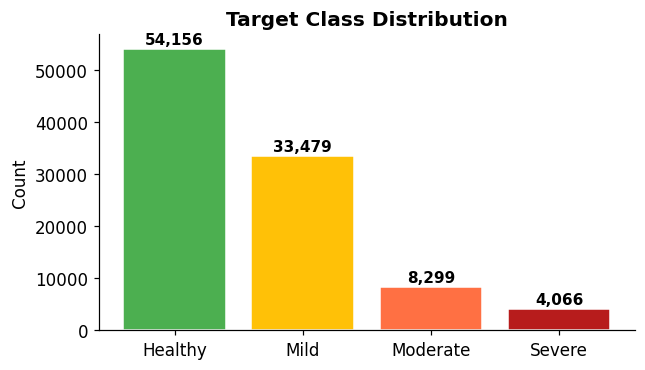

In [13]:
df = df_raw.copy()
TARGET     = "sleep_disorder_risk"
CLASS_ORDER = ["Healthy", "Mild", "Moderate", "Severe"]
PALETTE     = {"Healthy": "#4CAF50", "Mild": "#FFC107",
               "Moderate": "#FF7043", "Severe": "#B71C1C"}

fig, ax = plt.subplots(figsize=(6, 3.5))
vc2 = df[TARGET].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(vc2.index, vc2.values,
              color=[PALETTE[c] for c in vc2.index], edgecolor="white")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 300,
            f"{int(b.get_height()):,}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_title("Target Class Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

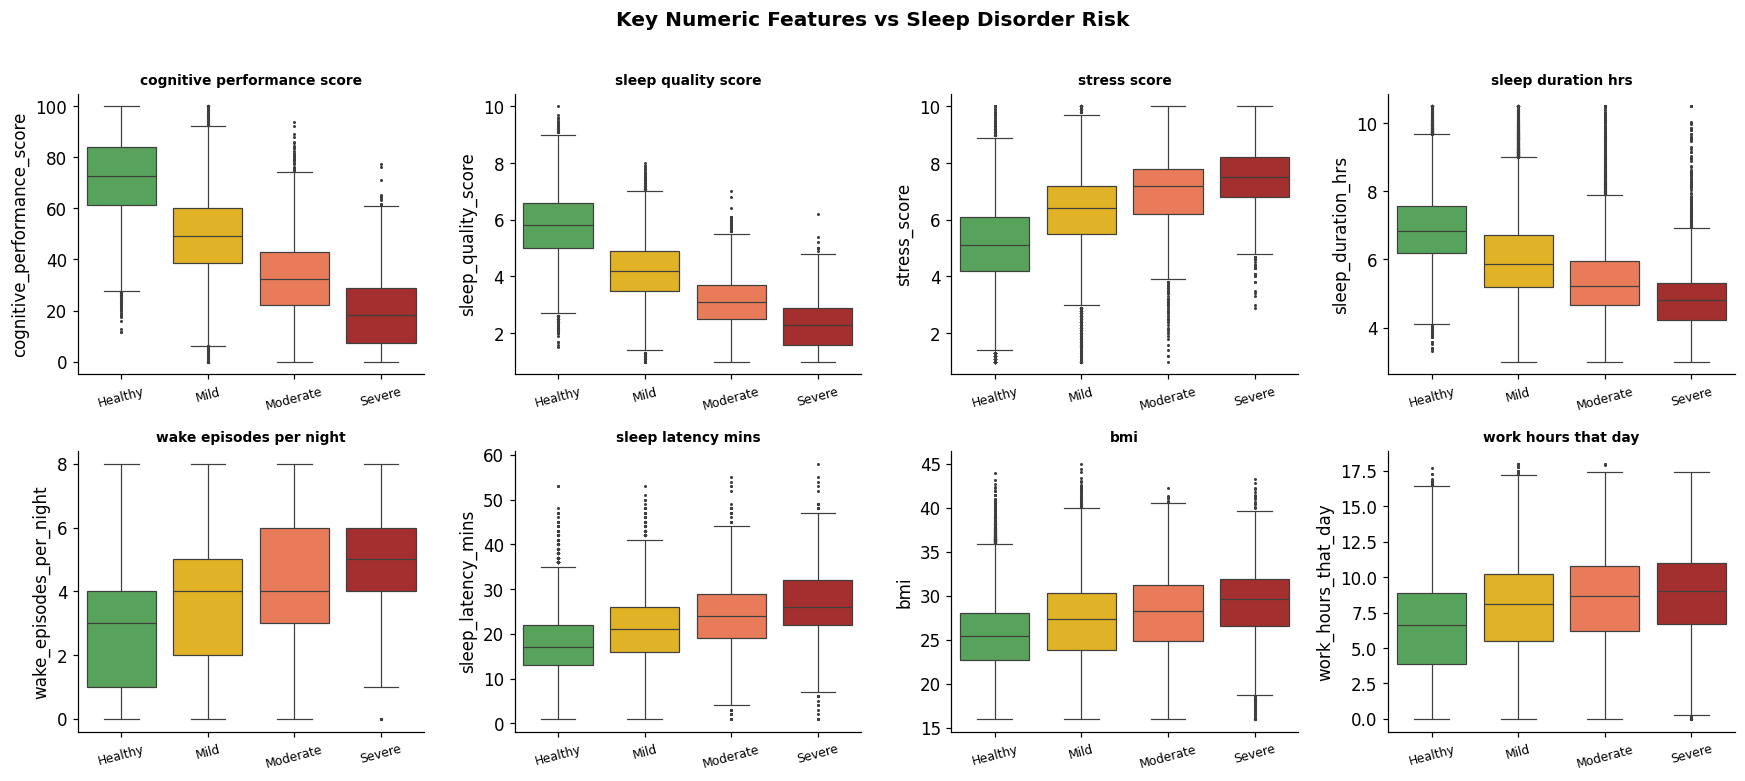

In [14]:
key_num = ["cognitive_performance_score", "sleep_quality_score", "stress_score",
           "sleep_duration_hrs", "wake_episodes_per_night", "sleep_latency_mins",
           "bmi", "work_hours_that_day"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), key_num):
    sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER,
                palette=PALETTE, ax=ax, linewidth=0.8, fliersize=1)
    ax.set_title(col.replace("_", " "), fontweight="bold", fontsize=9)
    ax.set_xlabel(""); ax.tick_params(axis="x", labelsize=8, rotation=15)
plt.suptitle("Key Numeric Features vs Sleep Disorder Risk", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

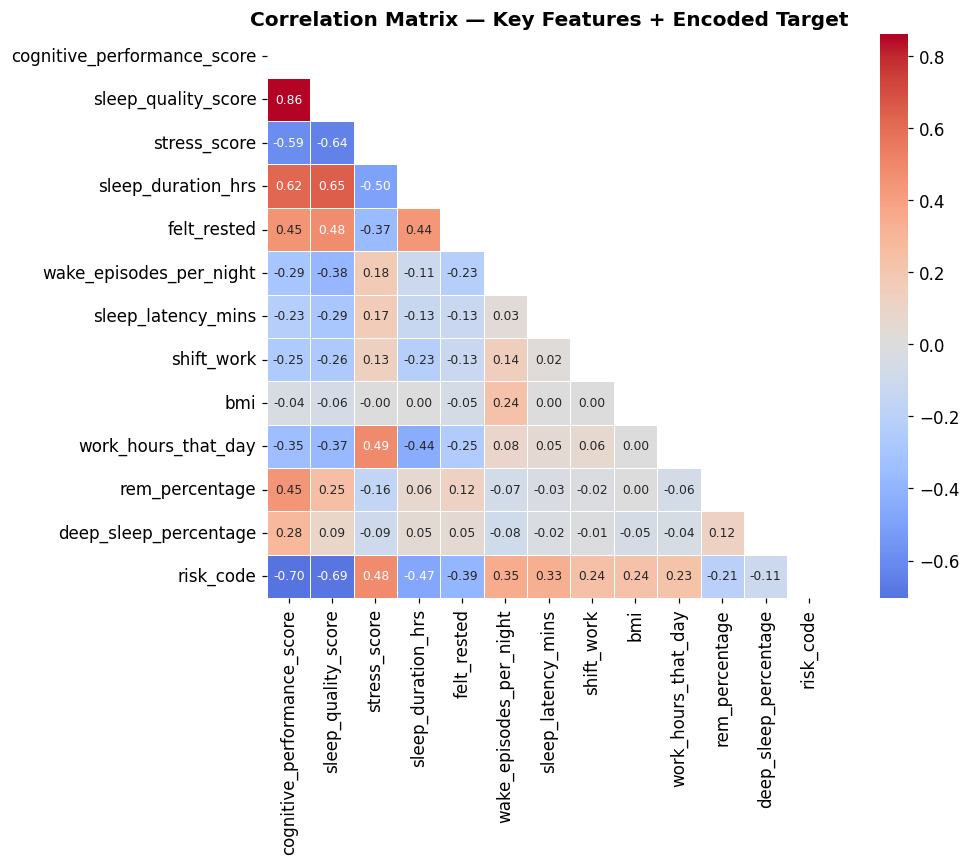

In [15]:
from sklearn.preprocessing import LabelEncoder
num_for_corr = ["cognitive_performance_score", "sleep_quality_score", "stress_score",
                "sleep_duration_hrs", "felt_rested", "wake_episodes_per_night",
                "sleep_latency_mins", "shift_work", "bmi", "work_hours_that_day",
                "rem_percentage", "deep_sleep_percentage"]

df_corr = df[num_for_corr].copy()
df_corr["risk_code"] = LabelEncoder().fit_transform(df[TARGET])

mask = np.triu(np.ones(df_corr.shape[1], dtype=bool))
plt.figure(figsize=(11, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, mask=mask, linewidths=0.4, square=True, annot_kws={"size": 8})
plt.title("Correlation Matrix — Key Features + Encoded Target", fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Preprocessing — Scaling & Encoding

**Justification of each step:**

| Step | Decision | Reason |
|------|----------|--------|
| Drop `person_id` | Applied | Pure identifier — zero predictive value |
| **StandardScaler on numeric features** | Applied | **Critical for MLP.** Neural networks use gradient descent; features with large ranges dominate the gradient updates. All numeric inputs are scaled to mean=0, std=1. This step was important for tree-based methods too, but is *essential* for MLPs. |
| **OneHotEncoding on nominal features** | Applied | Prevents the model from assuming ordinal relationships between categories (e.g., Male > Female). OHE is appropriate for all nominal variables. |
| Median Imputation | Applied (precaution) | No missing values found in EDA, but included as a safety net for unseen inference data. |
| Binary features (0/1) | No scaling needed | `exercise_day`, `sleep_aid_used`, `shift_work`, `felt_rested` are already in [0,1]; further scaling would not change their information content. |

In [16]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_model = df_raw.drop(columns=["person_id"])

le = LabelEncoder()
y = le.fit_transform(df_model[TARGET])
X = df_model.drop(columns=[TARGET])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("X shape:", X.shape)

Class mapping: {'Healthy': np.int64(0), 'Mild': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}
X shape: (100000, 30)


In [17]:
numeric_features = [
    "age", "bmi", "sleep_duration_hrs", "sleep_quality_score",
    "rem_percentage", "deep_sleep_percentage", "sleep_latency_mins",
    "wake_episodes_per_night", "caffeine_mg_before_bed",
    "alcohol_units_before_bed", "screen_time_before_bed_mins",
    "exercise_day", "steps_that_day", "nap_duration_mins",
    "stress_score", "work_hours_that_day", "heart_rate_resting_bpm",
    "sleep_aid_used", "shift_work", "room_temperature_celsius",
    "weekend_sleep_diff_hrs", "cognitive_performance_score", "felt_rested"
]

nominal_features = [
    "gender", "occupation", "country", "chronotype",
    "mental_health_condition", "season", "day_type"
]

assert set(numeric_features + nominal_features) == set(X.columns), "Column mismatch!"
print(f"Numeric features : {len(numeric_features)}")
print(f"Nominal features : {len(nominal_features)}")

Numeric features : 23
Nominal features : 7


In [18]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

nominal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("nom", nominal_transformer, nominal_features),
])

X_tmp = preprocessor.fit_transform(X.head(100))
print("Preprocessed shape (sample of 100):", X_tmp.shape)
print(f"23 numeric + OHE-expanded nominals = {X_tmp.shape[1]} total features")

Preprocessed shape (sample of 100): (100, 66)
23 numeric + OHE-expanded nominals = 66 total features


## 5. Train/Test Split with Stratification

**Justification:**

- **Stratify=y is necessary** because the target is imbalanced (Severe = ~4 %). Without stratification, random splits could produce a test set with very few Severe samples, making evaluation unreliable.  
- **80/20 split:** With 100 000 samples, a 20 % test set gives 20 000 held-out rows — sufficient for statistically stable evaluation of even the minority class (≈800 Severe samples in test).  
- The **same split** (same `random_state=42`) used in A1 is reused here so that A1 vs A2 comparisons are valid.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Train : {len(X_train):,} rows | Test : {len(X_test):,} rows")

for split, labels in [("Train", y_train), ("Test", y_test)]:
    counts = pd.Series(labels).map(dict(enumerate(le.classes_))).value_counts()
    pcts   = (counts / counts.sum() * 100).round(1)
    print(f"\n{split}:")
    print(pd.DataFrame({"Count": counts, "Pct %": pcts}))

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)
print(f"\nPreprocessed train shape : {X_train_pp.shape}")
print(f"Preprocessed test  shape : {X_test_pp.shape}")

Train : 80,000 rows | Test : 20,000 rows

Train:
          Count  Pct %
Healthy   43325   54.2
Mild      26783   33.5
Moderate   6639    8.3
Severe     3253    4.1

Test:
          Count  Pct %
Healthy   10831   54.2
Mild       6696   33.5
Moderate   1660    8.3
Severe      813    4.1

Preprocessed train shape : (80000, 66)
Preprocessed test  shape : (20000, 66)


## 6. Performance Metrics

**Justification of each metric:**

| Metric | Justification |
|--------|---------------|
| **F1 Score** | Primary optimisation target. Averages F1 across all 4 classes with **equal weight**, so minority classes (Moderate, Severe) are not drowned out by the majority. This is the correct metric for imbalanced multi-class problems. |
| **Accuracy** | Reported for completeness and TA comparison, but not used for optimisation — a model predicting "Healthy" always achieves ~54 % accuracy. |
| **Per-class Precision & Recall** | Reveals whether the model is better at avoiding false alarms (precision) or at catching every true case (recall) per risk level. |
| **Confusion Matrix** | Shows exactly which classes get confused — e.g. whether Severe cases are being misclassified as Moderate. |
| **Learning Curves** | Used to diagnose underfitting (train and val both low) vs overfitting (large gap between train and val). |

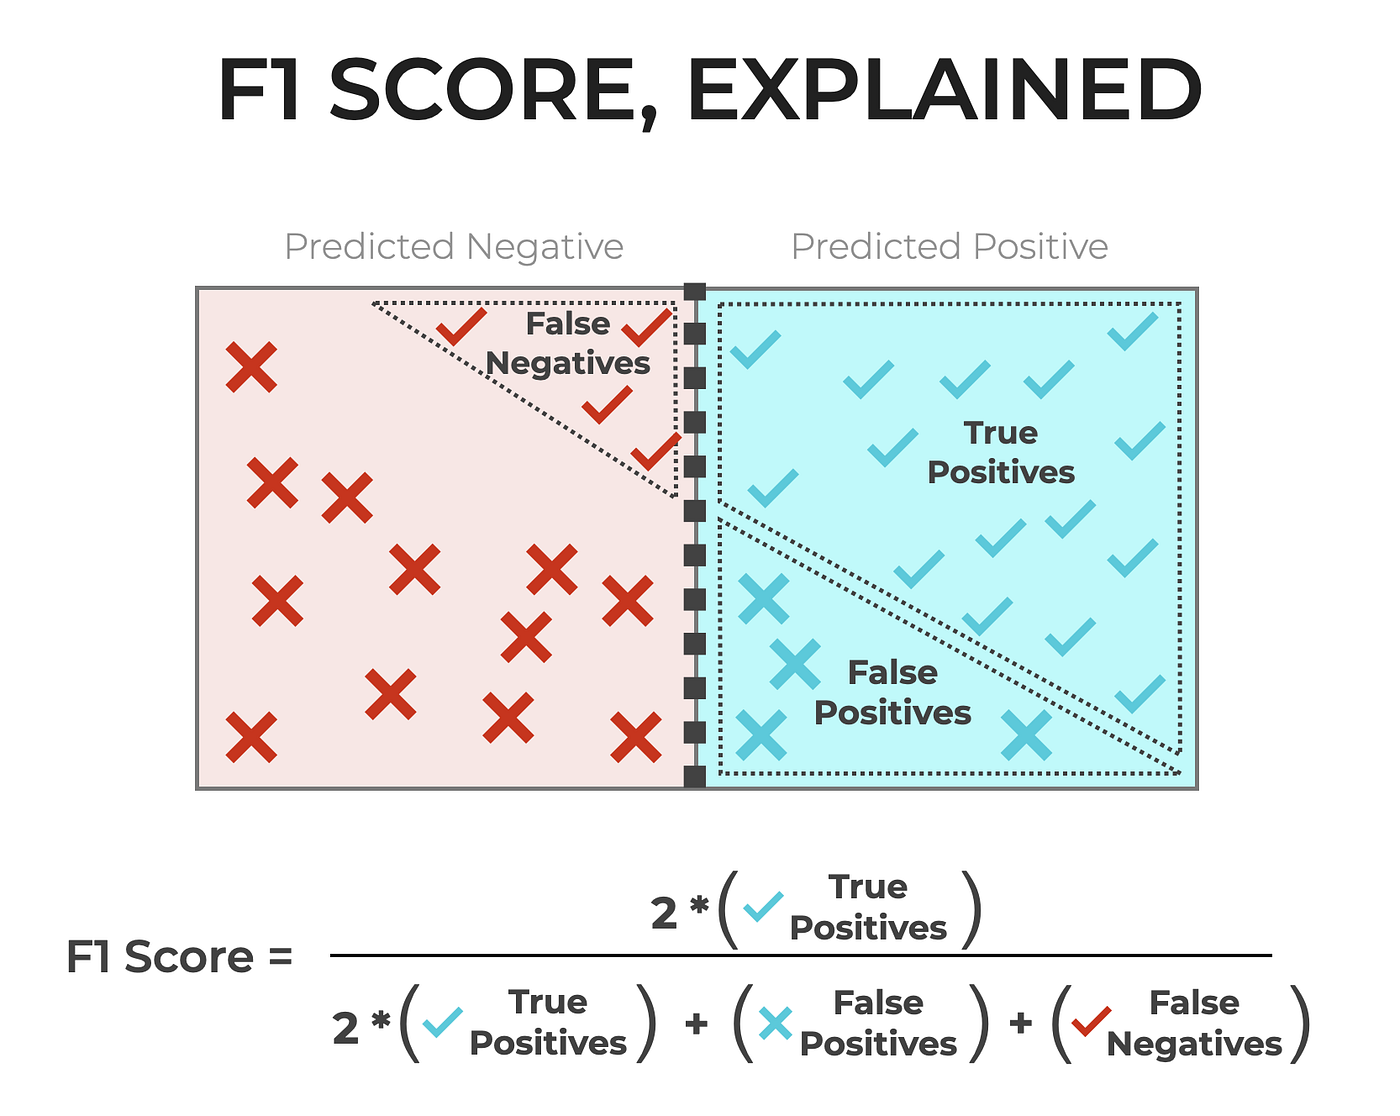

In [20]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    """Print train/test metrics, classification report, and confusion matrix."""
    ytr_pred = model.predict(X_tr)
    yte_pred = model.predict(X_te)

    tr_f1  = f1_score(y_tr, ytr_pred, average="macro")
    te_f1  = f1_score(y_te, yte_pred, average="macro")
    tr_acc = accuracy_score(y_tr, ytr_pred)
    te_acc = accuracy_score(y_te, yte_pred)
    gap    = tr_f1 - te_f1
    status = "OK" if gap < 0.05 else ("slight overfit" if gap < 0.15 else "OVERFIT")

    print("=" * 65)
    print(f"  {name}")
    print("=" * 65)
    print(f"  Train   Acc={tr_acc:.4f}   Macro-F1={tr_f1:.4f}")
    print(f"  Test    Acc={te_acc:.4f}   Macro-F1={te_f1:.4f}   [{status}]")
    print(f"  Overfit gap = {gap:.4f}")
    print()
    print(classification_report(y_te, yte_pred, target_names=le.classes_))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, yte_pred),
                           display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nConfusion Matrix", fontweight="bold", fontsize=10)
    plt.tight_layout(); plt.show()

    return {"name": name, "train_f1": tr_f1, "test_f1": te_f1,
            "train_acc": tr_acc, "test_acc": te_acc}

results = []
print("evaluate() helper defined.")

evaluate() helper defined.


## 7. Feature Selection (Slim Models)

**Justification:**  
With 30+ features after OHE expansion, feature selection serves two purposes:
1. **Regularisation effect** — removing noisy features reduces the variance of any model.
2. **Slim MLP** — a smaller input layer and fewer neurons reduce training time and risk of overfitting.

We use **Mutual Information** (measures non-linear dependence) to rank features, then confirm with a preliminary Random Forest. The top-12 features are selected for the slim variant.

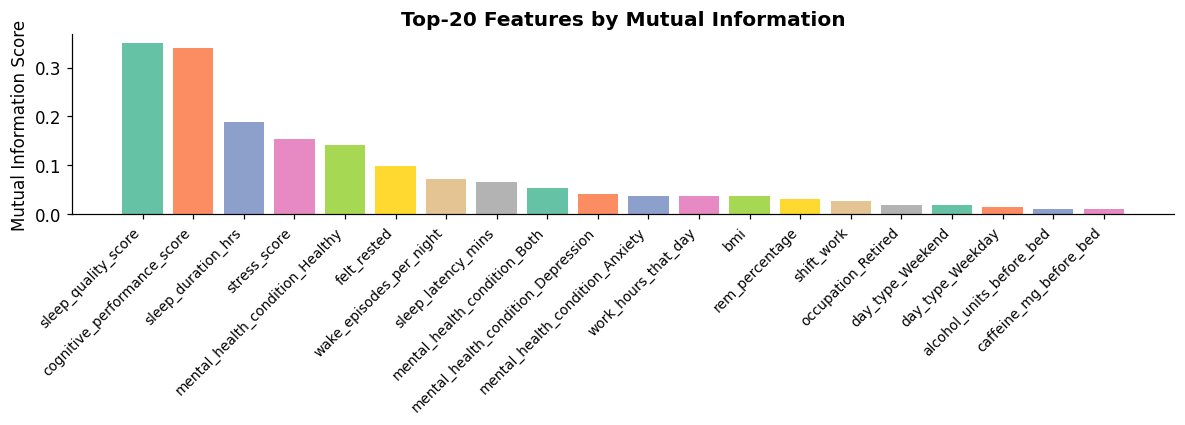

Top 12 features by Mutual Information:
sleep_quality_score                   0.350081
cognitive_performance_score           0.340316
sleep_duration_hrs                    0.188917
stress_score                          0.153015
mental_health_condition_Healthy       0.140994
felt_rested                           0.097855
wake_episodes_per_night               0.071485
sleep_latency_mins                    0.065783
mental_health_condition_Both          0.054090
mental_health_condition_Depression    0.040829
mental_health_condition_Anxiety       0.037658
work_hours_that_day                   0.036746


In [21]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

idx_sub = np.random.choice(len(X_train_pp), size=20_000, replace=False)
mi = mutual_info_classif(X_train_pp[idx_sub], y_train[idx_sub], random_state=SEED)

ohe_names = (preprocessor.named_transformers_["nom"]["encoder"]
             .get_feature_names_out(nominal_features).tolist())
all_feature_names = numeric_features + ohe_names

mi_series = pd.Series(mi, index=all_feature_names).sort_values(ascending=False)

top20 = mi_series.head(20)
plt.figure(figsize=(11, 4))
plt.bar(top20.index, top20.values, color=sns.color_palette("Set2", 20))
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Mutual Information Score")
plt.title("Top-20 Features by Mutual Information", fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 12 features by Mutual Information:")
print(mi_series.head(12).to_string())

In [22]:
TOP_K     = 12
selector  = SelectKBest(mutual_info_classif, k=TOP_K)
selector.fit(X_train_pp, y_train)
X_train_sel = selector.transform(X_train_pp)
X_test_sel  = selector.transform(X_test_pp)

selected_names = [n for n, m in zip(all_feature_names, selector.get_support()) if m]
print(f"SelectKBest top-{TOP_K} features:")
for i, fn in enumerate(selected_names, 1):
    print(f"  {i:2d}. {fn}")

SelectKBest top-12 features:
   1. bmi
   2. sleep_duration_hrs
   3. sleep_quality_score
   4. sleep_latency_mins
   5. wake_episodes_per_night
   6. stress_score
   7. work_hours_that_day
   8. cognitive_performance_score
   9. felt_rested
  10. mental_health_condition_Both
  11. mental_health_condition_Depression
  12. mental_health_condition_Healthy


# Assignment 2

## 8. Model Building, Evaluation & Optimisation — MLP

### What is a Multi-Layer Perceptron (MLP)?
- An **MLP** is a classic type of Neural Network, and it is provided by Sklearn [[docs]](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). 
- A neural network is like a "virtual brain" made up of layers of "neurons". Information flows **forward** through these layers, from the *input data*, through several hidden processing layers, all the way to the final prediction. Because data only moves in one direction, it is often called a **feed-forward** network.

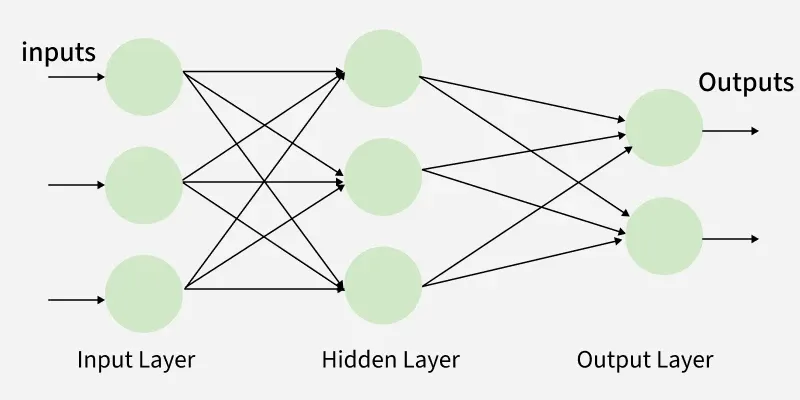

### MLP vs classic algorithms

* **Learning Complex Patterns (Non-linearity):** Real-world data is rarely perfectly separated by straight lines. By using specific math functions inside the network, the MLP can draw complex, curved boundaries to separate different categories.
* **Scalability for Large Data:** With 100,000 samples, we have a wonderfully large dataset. Simple models might underperform here, but neural networks thrive and learn better when given a lot of data.
* **Automatic Feature Learning:** Instead of us having to manually figure out which combinations of features are important, the MLP's hidden layers figure it out automatically during training.
* **A Strong Benchmark:** Building an MLP gives us a powerful neural network to compare against the simpler tree-based and probabilistic models we built in Assignment 1.

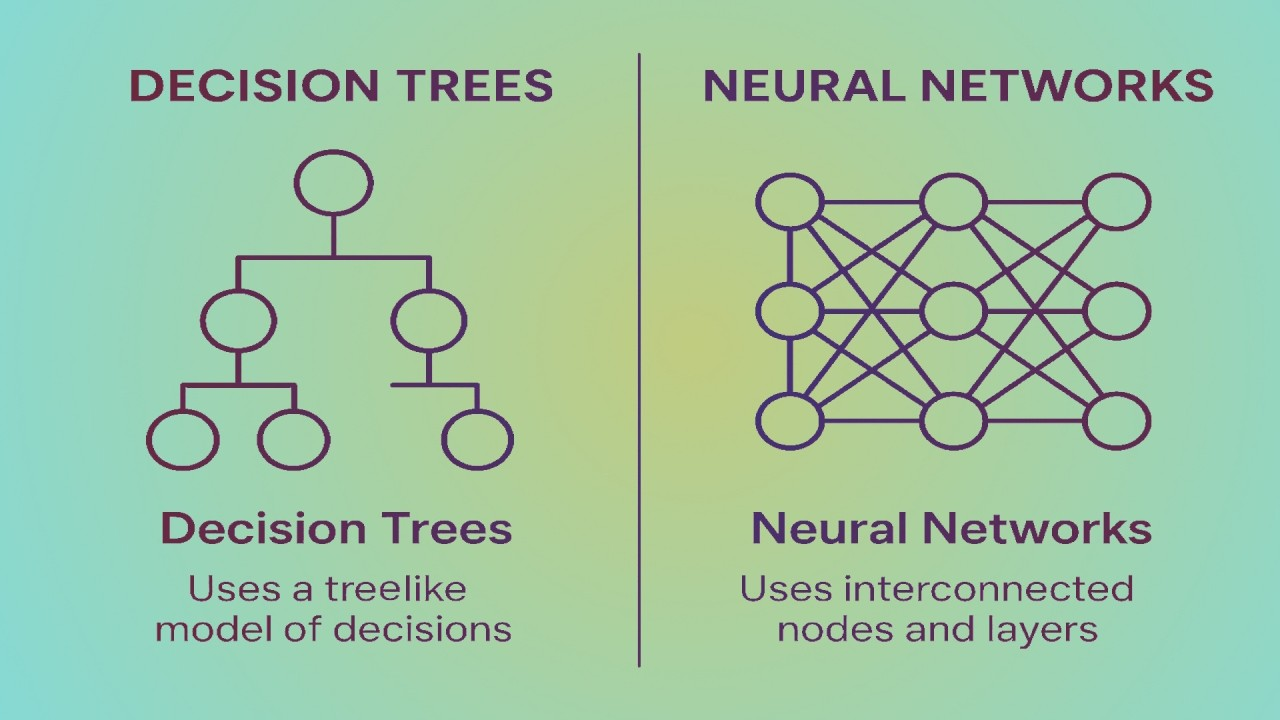

---

### Activation Functions

To understand how an MLP learns, we have to talk about **Activation Functions**. 

Imagine a neuron in the network receiving data. The activation function acts as a **gatekeeper**. It looks at the incoming data, performs a mathematical calculation, and decides: *"Is this information important? Should I pass a strong signal to the next layer, a weak one, or no signal at all?"* 

- Without activation functions, the whole network would just be doing basic, flat linear math, no matter how many layers you add, it would act like a single straight line.
- Activation functions introduce **non-linearity**, allowing the network to learn curves, shapes, and complex relationships.

### Comparison Between Activation Functions
We will discuss three of the most famous activation functions used in training neural networks:

**1. Sigmoid:**
* **How it works:** It takes any number and squishes it into a smooth curve between 0 and 1. 
* **The downside:** While historically popular, it suffers from a problem called the "vanishing gradient." In deep networks, the learning signals get so tiny as they pass backward through the Sigmoid curves that the early layers stop learning altogether. 

**2. Tanh (Hyperbolic Tangent):**
* **How it works:** Think of Tanh as Sigmoid's upgraded sibling. Instead of squishing numbers between 0 and 1, it maps them to a smooth curve between -1 and 1 using $f(x) = \tanh(x)$.
* **Pros & Cons:** Because its output is centered exactly at zero, it naturally balances out positive and negative signals, often helping the network learn faster than a standard Sigmoid. However, its curves still flatten out at the extremes, meaning it hasn't completely escaped the vanishing gradient problem.

**3. ReLU (Rectified Linear Unit):**
* **How it works:** It uses a very simple mathematical rule: $f(x) = \max(0, x)$. If the input is negative, it outputs exactly 0. If it is positive, it passes the number through completely unchanged. 
* **Why we use it:** Because it doesn't squish positive numbers, the "learning signal" stays strong throughout the entire network. It is simpler, much faster to compute, and heavily prevents the vanishing gradient problem. **This is why we chose ReLU for our hidden layers.**

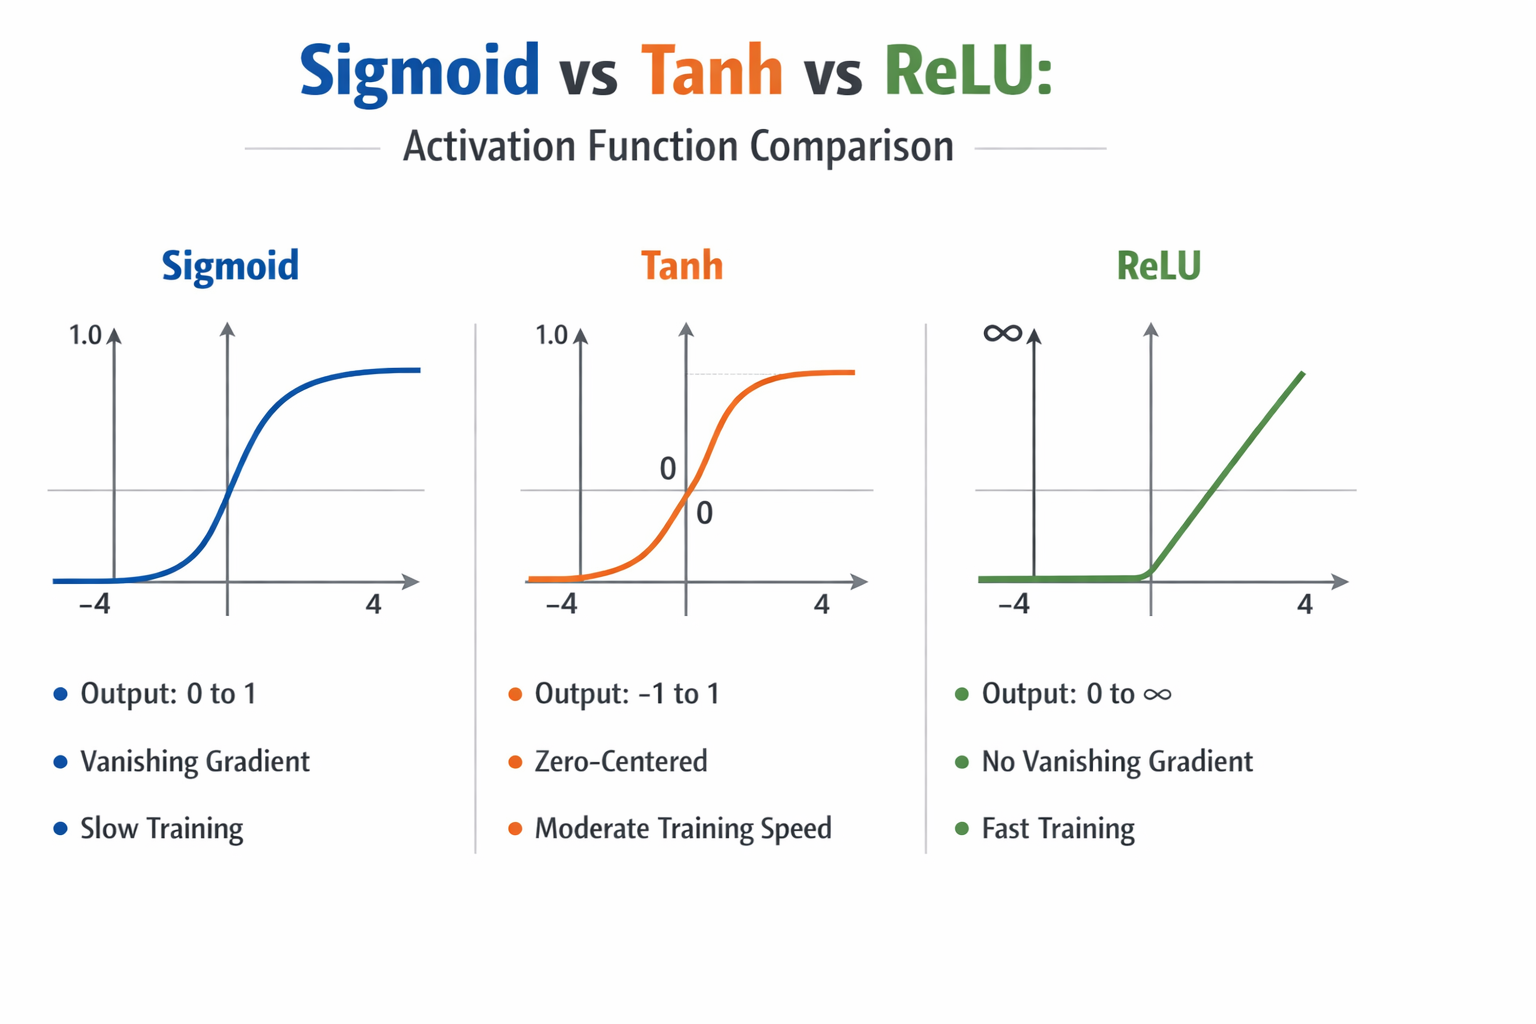

---

### Our Network Architecture

Below is the specific structure we designed for this classification task. We take our input features, pass them through three distinct hidden layers that get progressively smaller (funneling the information down to the most important concepts), and finally output a prediction for our 4 distinct classes.

---

### Step-by-Step Methodology

To ensure we build the best possible model, we will follow a strict, 7-step process:

1.  **Baseline MLP:** We start by training a default `MLPClassifier` with basic settings. This gives us a baseline score to beat.
2.  **Architecture Exploration:** We experiment with the shape of the network, testing different numbers of layers and neurons to see what handles our data best.
3.  **Regularisation:** We apply L2 regularization (`alpha`) and Early Stopping. This stops the model from training too long and memorizing the training data (preventing overfitting).
4.  **Hyperparameter Search (`RandomizedSearchCV`):** We let the computer randomly test hundreds of different combinations of settings to automatically find the optimal configuration.
5.  **Learning Curve Analysis:** We plot the model's learning progress over time to visually diagnose if it needs more data, is underfitting, or is overfitting.
6.  **Final Test Set Evaluation:** We test our best model on totally unseen data to get an honest, unbiased score of how it will perform in the real world.
7.  **Slim MLP:** Finally, we take our best settings but train the network using only the top 12 most important features, seeing if we can get the same great results with a faster, lighter model.

### 8.1 Baseline MLP

### Step 1: Baseline MLP Setup

We established a default model to serve as a benchmark. Here is the rationale behind our configuration:

* **`StratifiedKFold(n_splits=5)`:** We use 5-fold cross-validation to get a reliable score. *Stratified* ensures the exact ratio of our 4 target classes is perfectly preserved in every test chunk for a fair evaluation.
* **`hidden_layer_sizes=(100,)`:** We start with a single layer of 100 neurons as a lightweight, standard starting point before exploring deeper architectures.
* **`activation="relu"`:** We chose ReLU over Sigmoid or Tanh because it heavily reduces the vanishing gradient problem, allowing the network to learn faster and more effectively.
* **`max_iter=300`:** This sets a reasonable ceiling, giving the model enough time to converge without training endlessly.
* **Early Stopping Defense (`early_stopping`, `validation_fraction`, `n_iter_no_change`):** Neural networks can easily memorize training data (overfitting). We prevent this by hiding 10% of the data during training; if the model's score on that hidden 10% doesn't improve for 15 consecutive passes, it stops training early.
* **`evaluate(...)`:** Finally, we run our custom tracking function to save this baseline score, giving us a hard number to beat in our upcoming hyperparameter search.

  MLP Baseline (100,)
  Train   Acc=0.9115   Macro-F1=0.8574
  Test    Acc=0.8815   Macro-F1=0.7976   [slight overfit]
  Overfit gap = 0.0597

              precision    recall  f1-score   support

     Healthy       0.94      0.95      0.95     10831
        Mild       0.84      0.86      0.85      6696
    Moderate       0.67      0.58      0.62      1660
      Severe       0.81      0.75      0.78       813

    accuracy                           0.88     20000
   macro avg       0.81      0.78      0.80     20000
weighted avg       0.88      0.88      0.88     20000



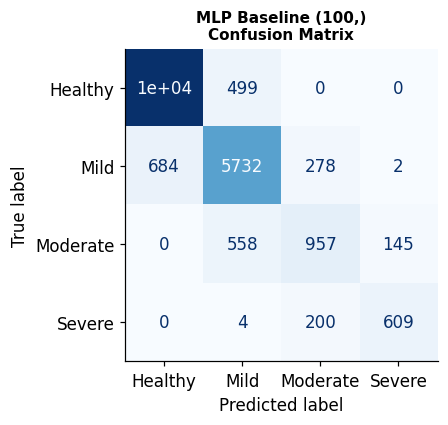

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.model_selection import learning_curve

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

mlp_base = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    max_iter=300,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
mlp_base.fit(X_train_pp, y_train)
r = evaluate(mlp_base, X_train_pp, y_train, X_test_pp, y_test,
             "MLP Baseline (100,)")
results.append(r)

### 8.2 Architecture Exploration (Depth vs Width)

Now we test different shapes for our network to find the the best tradeoff, such we avoid overfitting and underfitting. Here are the key decisions made in this step:

* **The Search Space (`arch_configs`):** We systematically test 9 configurations, ranging from small/shallow (1 layer of 50 neurons) to deep/heavy (4 layers). This helps us see exactly when adding more layers stops improving performance.
* **Speeding up the Search (`np.random.choice`):** Training 9 heavy neural networks on 100,000 rows would take a massive amount of time. Instead, we randomly sample a subset of 30,000 rows to quickly identify the best architecture without waiting hours.
* **Slight Parameter Tweaks (`max_iter`, `alpha`):** We bumped the maximum iterations up to 400 because deeper networks need more time to converge. We also kept a standard L2 regularization (`alpha=1e-4`) to keep the network's weights disciplined.
* **The Evaluation Metric (`f1_score(average="macro")`):** We use F1-score instead of simple accuracy. This ensures the model is graded fairly on how well it predicts *all* 4 classes equally, preventing it from just guessing the most common class.
* **Automated Selection:** We track the Train and Test scores for each run and automatically select the architecture with the highest Test F1 score to carry forward into our final hyperparameter tuning.

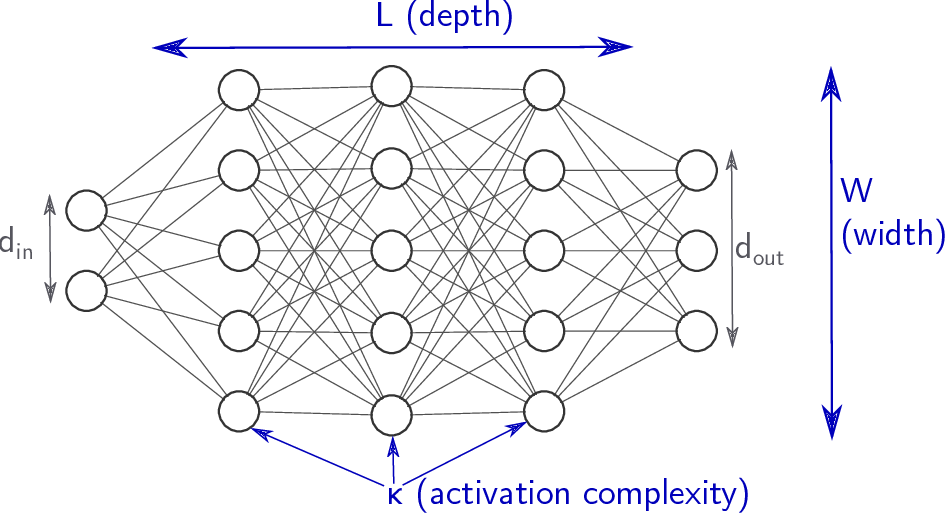

In [24]:
# Depth exploration 
arch_configs = [
    (50,),
    (100,),
    (200,),
    (100, 50),
    (200, 100),
    (256, 128),
    (256, 128, 64),
    (512, 256, 128),
    (256, 128, 64, 32),
]
arch_labels, arch_tr, arch_te = [], [], []

print("Exploring architectures:")

for arch in arch_configs:
    m = MLPClassifier(
        hidden_layer_sizes=arch, 
        activation="relu", 
        max_iter=400,
        random_state=SEED, 
        early_stopping=True, 
        validation_fraction=0.1,
        n_iter_no_change=15, 
        alpha=1e-4
    )

    idx = np.random.choice(len(X_train_pp), 30_000, replace=False)
    m.fit(X_train_pp[idx], y_train[idx])
    
    tr_f = f1_score(y_train[idx], m.predict(X_train_pp[idx]), average="macro")
    te_f = f1_score(y_test,       m.predict(X_test_pp),       average="macro")
    
    arch_labels.append(str(arch))
    arch_tr.append(tr_f)
    arch_te.append(te_f)
    print(f"  {str(arch):35s}  Train F1={tr_f:.3f}  Test F1={te_f:.3f}")

best_idx = int(np.argmax(arch_te))
print(f"\nBest architecture on test F1: {arch_labels[best_idx]} (F1={arch_te[best_idx]:.4f})")

Exploring architectures:
  (50,)                                Train F1=0.808  Test F1=0.758
  (100,)                               Train F1=0.804  Test F1=0.757
  (200,)                               Train F1=0.832  Test F1=0.767
  (100, 50)                            Train F1=0.802  Test F1=0.759
  (200, 100)                           Train F1=0.832  Test F1=0.759
  (256, 128)                           Train F1=0.904  Test F1=0.754
  (256, 128, 64)                       Train F1=0.845  Test F1=0.760
  (512, 256, 128)                      Train F1=0.853  Test F1=0.771
  (256, 128, 64, 32)                   Train F1=0.841  Test F1=0.766

Best architecture on test F1: (512, 256, 128) (F1=0.7709)


In the following plot, we will compare the results:

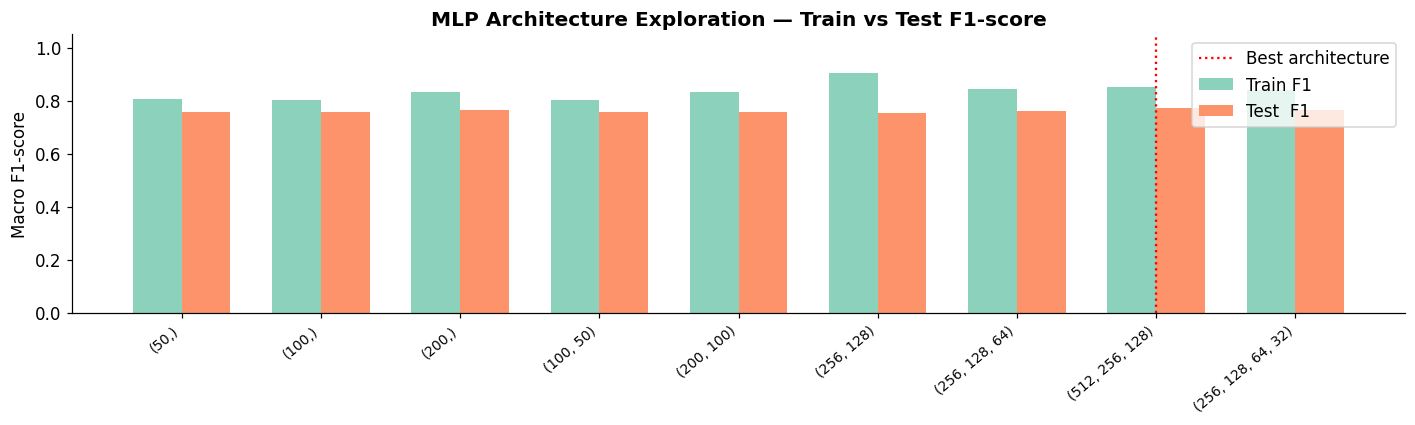

In [25]:
# Architecture comparison plot
x = np.arange(len(arch_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x - w/2, arch_tr, w, label="Train F1", alpha=0.75)
ax.bar(x + w/2, arch_te, w, label="Test  F1", alpha=0.95)
ax.set_xticks(x)
ax.set_xticklabels(arch_labels, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Macro F1-score"); ax.set_ylim(0, 1.05)
ax.set_title("MLP Architecture Exploration — Train vs Test F1-score",
             fontweight="bold")
ax.axvline(best_idx, color="red", linestyle=":", linewidth=1.5,
           label="Best architecture")
ax.legend(); plt.tight_layout(); plt.show()

### 8.3 Regularisation & Overfitting Analysis

Two main regularisation mechanisms are explored:
- **L2 weight decay (`alpha`):** Penalises large weights; prevents over-complex solutions.
- **Early stopping:** Halts training when validation loss stops improving; prevents too many gradient steps on the training set.
- **Dropout** is not directly exposed in `sklearn.MLPClassifier`, but `alpha` and early stopping together provide sufficient regularisation for this dataset size.

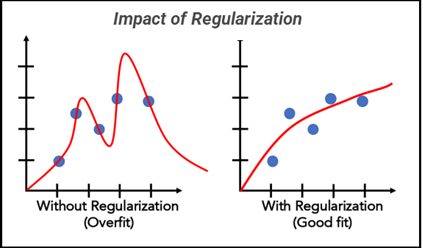

Sweeping L2 regularisation alpha…
  alpha=1.0e-05  Train F1=0.899  Test F1=0.767
  alpha=1.0e-04  Train F1=0.841  Test F1=0.766
  alpha=1.0e-03  Train F1=0.976  Test F1=0.749
  alpha=1.0e-02  Train F1=0.874  Test F1=0.777
  alpha=1.0e-01  Train F1=0.885  Test F1=0.778
  alpha=1.0e+00  Train F1=0.812  Test F1=0.779


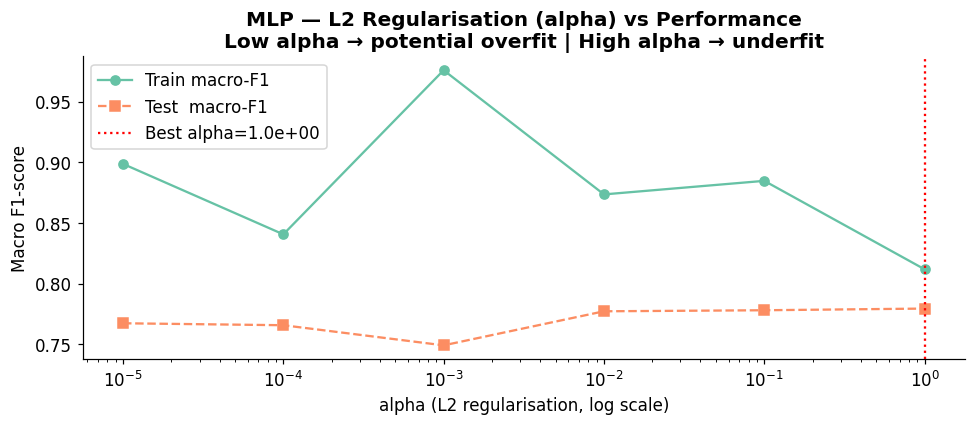

Best alpha from sweep: 1.0e+00


In [26]:
alpha_vals = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]
alpha_tr, alpha_te = [], []

print("Sweeping L2 regularisation alpha…")
for a in alpha_vals:
    m = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation="relu",
        alpha=a, max_iter=400, random_state=SEED,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=15
    )
    idx = np.random.choice(len(X_train_pp), 30_000, replace=False)
    m.fit(X_train_pp[idx], y_train[idx])
    alpha_tr.append(f1_score(y_train[idx], m.predict(X_train_pp[idx]), average="macro"))
    alpha_te.append(f1_score(y_test,       m.predict(X_test_pp),       average="macro"))
    print(f"  alpha={a:.1e}  Train F1={alpha_tr[-1]:.3f}  Test F1={alpha_te[-1]:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alpha_vals, alpha_tr, "o-",  label="Train macro-F1")
ax.semilogx(alpha_vals, alpha_te, "s--", label="Test  macro-F1")
best_a = alpha_vals[int(np.argmax(alpha_te))]
ax.axvline(best_a, color="red", linestyle=":", label=f"Best alpha={best_a:.1e}")
ax.set_xlabel("alpha (L2 regularisation, log scale)")
ax.set_ylabel("Macro F1-score")
ax.set_title("MLP — L2 Regularisation (alpha) vs Performance\n"
             "Low alpha → potential overfit | High alpha → underfit",
             fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Best alpha from sweep: {best_a:.1e}")

### 8.4 Hyperparameter Optimisation — RandomizedSearchCV

**Why RandomizedSearchCV instead of GridSearchCV?**  
The MLP hyperparameter space is large (architecture × activation × alpha × learning rate × solver). An exhaustive grid would require hundreds of fits on 100 k samples. RandomizedSearchCV samples a fixed number of configurations (`n_iter=25`) efficiently, typically finding near-optimal configurations in a fraction of the time.

**Search space:**

| Hyperparameter | Values explored | Rationale |
|----------------|----------------|-----------|
| `hidden_layer_sizes` | (100,), (200,100), (256,128), (256,128,64), (512,256,128) | Width/depth trade-off from architecture exploration |
| `activation` | relu, tanh | ReLU is typically better; tanh included as alternative |
| `alpha` | log-uniform [1e-5, 1e-1] | L2 regularisation strength |
| `learning_rate_init` | 1e-4, 5e-4, 1e-3, 5e-3 | Controls gradient step size |
| `solver` | adam, sgd | Adam is usually best; SGD with momentum included |
| `batch_size` | 64, 128, 256 | Mini-batch size for stochastic gradient updates |

In [ ]:
from scipy.stats import loguniform

param_dist = {
    "hidden_layer_sizes": [
        (100,), (200, 100), (256, 128), (256, 128, 64),
        (512, 256, 128), (128, 64), (256, 128, 64, 32)
    ],
    "activation":         ["relu", "tanh"],
    "alpha":              loguniform(1e-5, 1e-1),
    "learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
    "solver":             ["adam", "sgd"],
    "batch_size":         [64, 128, 256],
}

mlp_search_base = MLPClassifier(
    max_iter=400,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
)

mlp_rs = RandomizedSearchCV(
    mlp_search_base,
    param_distributions=param_dist,
    n_iter=3, # we can increase it for better results. Lowered it for development purpose. Reccomended value is between 20-30 iterations
    scoring="f1_macro",
    cv=cv5,
    n_jobs=-1,
    random_state=SEED,
    verbose=2,
    refit=True,
)

print("Starting RandomizedSearchCV (25 iterations × 5-fold CV)…")
print("This will take several minutes on 100k rows.")
mlp_rs.fit(X_train_pp, y_train)

print("\n" + "="*60)
print("Best hyperparameters:")
for k, v in mlp_rs.best_params_.items():
    print(f"  {k:25s} = {v}")
print(f"\nBest CV macro-F1 : {mlp_rs.best_score_:.4f}")

Starting RandomizedSearchCV (25 iterations × 5-fold CV)…
This will take several minutes on 100k rows.
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best hyperparameters:
  activation                = relu
  alpha                     = 0.015352246941973482
  batch_size                = 256
  hidden_layer_sizes        = (256, 128)
  learning_rate_init        = 0.005
  solver                    = adam

Best CV macro-F1 : 0.8071


In [29]:
cv_results = pd.DataFrame(mlp_rs.cv_results_)
top10 = (cv_results[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
         .sort_values("rank_test_score")
         .head(10)
         .reset_index(drop=True))
top10.index += 1
print("Top-10 RandomizedSearchCV configurations:")
print(top10[["rank_test_score", "mean_test_score", "std_test_score"]].to_string())

Top-10 RandomizedSearchCV configurations:
   rank_test_score  mean_test_score  std_test_score
1                1         0.807052        0.010749
2                2         0.796984        0.011897
3                3         0.740746        0.001957


### 8.5 Best MLP — Full Evaluation

  MLP (tuned — full features)
  Train   Acc=0.9319   Macro-F1=0.8863
  Test    Acc=0.8901   Macro-F1=0.8215   [slight overfit]
  Overfit gap = 0.0649

              precision    recall  f1-score   support

     Healthy       0.95      0.95      0.95     10831
        Mild       0.86      0.86      0.86      6696
    Moderate       0.66      0.70      0.68      1660
      Severe       0.84      0.76      0.80       813

    accuracy                           0.89     20000
   macro avg       0.83      0.82      0.82     20000
weighted avg       0.89      0.89      0.89     20000



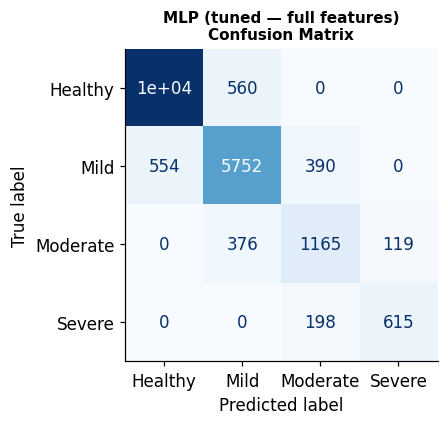

In [30]:
mlp_best = mlp_rs.best_estimator_
r = evaluate(mlp_best, X_train_pp, y_train, X_test_pp, y_test,
             "MLP (tuned — full features)")
results.append(r)

### 8.6 Learning Curve — Underfitting / Overfitting Diagnosis

The **learning curve** plots training and cross-validation F1 as a function of training set size.  
- If both curves are low and converge → **underfitting** (model too simple; consider deeper architecture)  
- If there is a large gap with train high and val low → **overfitting** (increase alpha or reduce complexity)  
- If both curves are high and close → **well-generalised** 

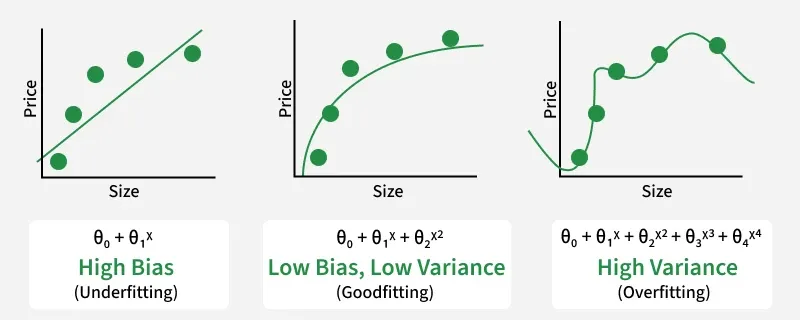

Computing learning curve (may take a few minutes)…


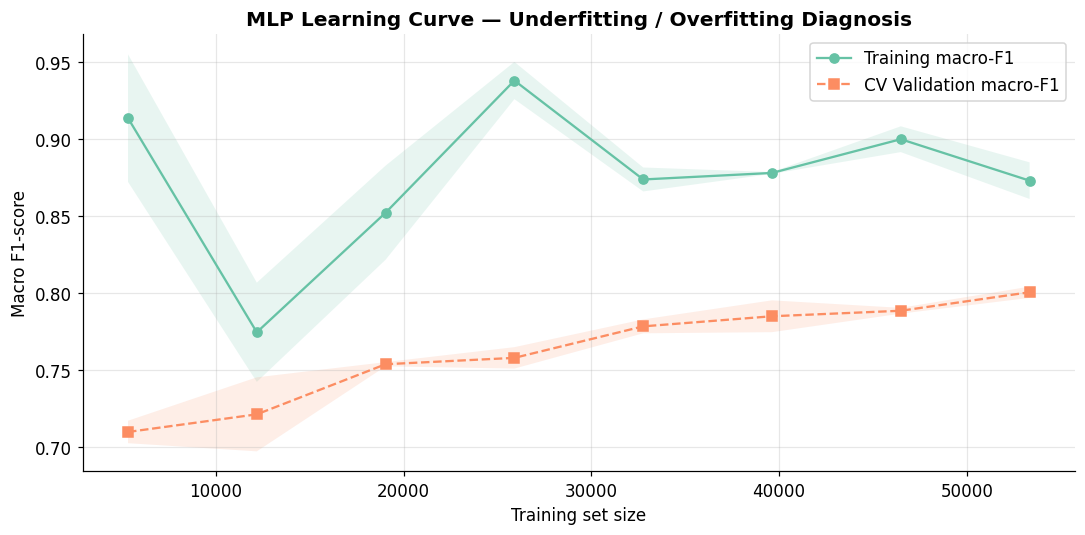

Final train F1  : 0.8730
Final val   F1  : 0.8005
Gap             : 0.0725  →  ~ Slight overfit


In [31]:
print("Computing learning curve (may take a few minutes)…")
train_sizes, train_scores, val_scores = learning_curve(
    mlp_best,
    X_train_pp, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="f1_macro",
    n_jobs=-1,
    verbose=0,
)

tr_mean  = train_scores.mean(axis=1)
tr_std   = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.15)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.plot(train_sizes, tr_mean,  "o-",  label="Training macro-F1")
plt.plot(train_sizes, val_mean, "s--", label="CV Validation macro-F1")
plt.xlabel("Training set size")
plt.ylabel("Macro F1-score")
plt.title("MLP Learning Curve — Underfitting / Overfitting Diagnosis",
          fontweight="bold")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

gap = tr_mean[-1] - val_mean[-1]
print(f"Final train F1  : {tr_mean[-1]:.4f}")
print(f"Final val   F1  : {val_mean[-1]:.4f}")
print(f"Gap             : {gap:.4f}  →  {'✓ Well-generalised' if gap < 0.05 else '~ Slight overfit' if gap < 0.15 else '✗ OVERFIT'}")

### 8.7 Training Loss Curve

### Step 5: Learning Curve Analysis (Loss vs. Cost)

Before analyzing the graph, it helps to understand the difference between **Loss** and **Cost**, as they represent different scales of the model's errors:

* **Loss:** The error penalty calculated for a **single data point**. It measures how "wrong" the model's prediction was for one specific sample.
* **Cost:** The **average loss** across the **entire dataset** (or a training batch). This is the macro-level metric the network actually uses to evaluate its performance and update its weights.
* **The Goal:** During training, the network's entire objective is to minimize the total Cost. A **Loss Curve** (which technically plots the average training cost per epoch) shows us a visual diary of how the model's errors decreased over time.

Here is the rationale behind our plotting and diagnostic code:

* **Safety Check (`hasattr`):** We check if the historical logs exist. If the model was loaded from a saved cache file instead of being trained fresh, scikit-learn clears these properties.
* **Tracking Training Progress (`loss_curve_`):** We plot the training cost to ensure it smoothly slopes downward, proving the model is successfully minimizing its errors over time.
* **Dual-Axis Tracking (`ax.twinx()`):** We overlay the validation score (orange dashed line) on a secondary Y-axis to compare training progress against real-world generalization side-by-side.
* **Diagnosing Overfitting:** By looking at both lines, we can see if the training loss keeps dropping while the validation score starts getting worse. If that happens, the model is memorizing the data.
* **Verifying Early Stopping:** The final print statement tells us the exact epoch where training stopped, confirming that our safety system successfully stepped in the moment validation scores plateaued.

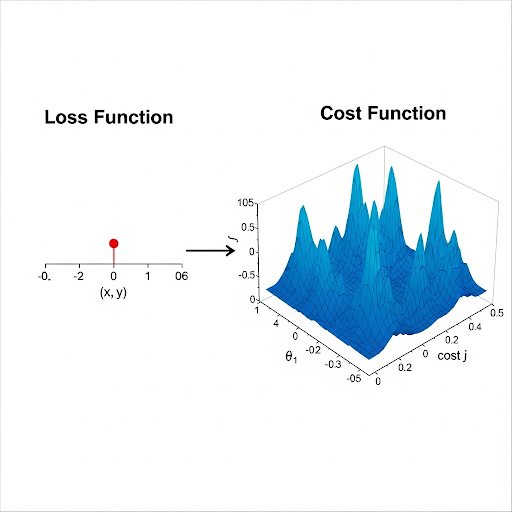

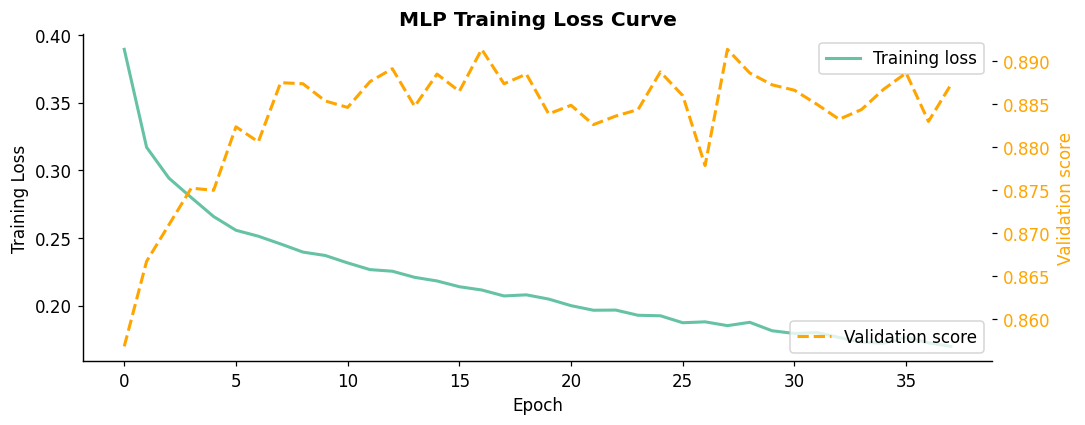

Training stopped at epoch 38 (early stopping threshold: 20 epochs without improvement)


In [32]:
# Loss curve
if hasattr(mlp_best, "loss_curve_"):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(mlp_best.loss_curve_, label="Training loss", linewidth=2)
    if hasattr(mlp_best, "validation_scores_") and mlp_best.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp_best.validation_scores_, color="orange",
                 linestyle="--", linewidth=2, label="Validation score")
        ax2.set_ylabel("Validation score", color="orange")
        ax2.tick_params(axis="y", labelcolor="orange")
        ax2.legend(loc="lower right")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("MLP Training Loss Curve", fontweight="bold")
    ax.legend(loc="upper right"); plt.tight_layout(); plt.show()
    print(f"Training stopped at epoch {len(mlp_best.loss_curve_)} "
          f"(early stopping threshold: {mlp_best.n_iter_no_change} epochs without improvement)")
else:
    print("Loss curve not available — model may have been loaded from cache.")

### 8.8 Slim MLP (Top-12 Features)

**Justification:** The slim variant uses only the top-12 features selected in Section 7. This tests whether the MLP can generalise with fewer inputs, reducing the risk of the model relying on noisy features. The same best hyperparameters found by RandomizedSearchCV are used to ensure a fair comparison with the full-feature MLP.

  MLP (slim top-12)
  Train   Acc=0.9128   Macro-F1=0.8386
  Test    Acc=0.9019   Macro-F1=0.8171   [OK]
  Overfit gap = 0.0215

              precision    recall  f1-score   support

     Healthy       0.95      0.97      0.96     10831
        Mild       0.89      0.86      0.88      6696
    Moderate       0.67      0.68      0.67      1660
      Severe       0.82      0.70      0.76       813

    accuracy                           0.90     20000
   macro avg       0.83      0.80      0.82     20000
weighted avg       0.90      0.90      0.90     20000



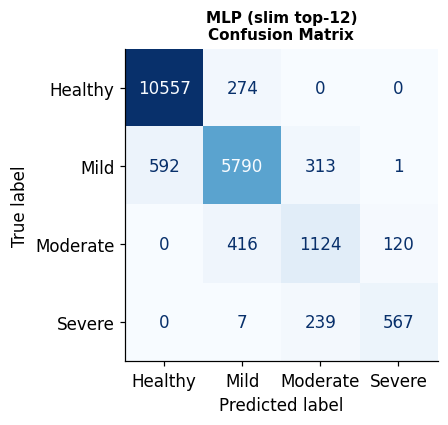


Full MLP test macro-F1 : 0.8215
Slim MLP test macro-F1 : 0.8171
Drop from feature selection : +0.0044


In [33]:
mlp_slim = MLPClassifier(**mlp_rs.best_params_,
                         max_iter=400, random_state=SEED,
                         early_stopping=True,
                         validation_fraction=0.1,
                         n_iter_no_change=20)
mlp_slim.fit(X_train_sel, y_train)
r = evaluate(mlp_slim, X_train_sel, y_train, X_test_sel, y_test,
             f"MLP (slim top-{TOP_K})")
results.append(r)

slim_gap  = r["train_f1"] - r["test_f1"]
full_test = [x for x in results if x["name"] == "MLP (tuned — full features)"][0]["test_f1"]
slim_test = r["test_f1"]
print(f"\nFull MLP test macro-F1 : {full_test:.4f}")
print(f"Slim MLP test macro-F1 : {slim_test:.4f}")
print(f"Drop from feature selection : {full_test - slim_test:+.4f}")

## 9. Feature Engineering & Re-evaluation

The same 5 domain-informed features introduced in A1 are reused and evaluated with the MLP to measure their impact on the neural network specifically.

| New Feature | Formula | Rationale |
|-------------|---------|-----------|
| `sleep_efficiency` | `(sleep_duration_hrs × sleep_quality_score) / 10` | Combined quality-duration proxy for restorative sleep |
| `total_sleep_disruption` | `sleep_latency_mins + wake_episodes_per_night × 10` | Penalises both sleep-onset difficulty and fragmented sleep |
| `pre_bed_stimulant_load` | `caffeine_mg / 100 + alcohol_units` | Combined pre-bed arousal burden |
| `cognitive_stress_ratio` | `cognitive_performance_score / (stress_score + 1)` | High cognition + low stress → healthy balance |
| `screen_caffeine_index` | `screen_time × (1 + caffeine_mg / 200)` | Interaction of two arousal-promoting pre-bed behaviours |

**Why re-evaluate with MLP?** Unlike tree-based models, the MLP can in principle learn these interactions from raw features. Feature engineering tests whether explicit construction still helps, or whether the MLP's non-linearity already captures these patterns.

In [34]:
def add_features(df_in):
    d = df_in.copy()
    d["sleep_efficiency"]       = (d["sleep_duration_hrs"] * d["sleep_quality_score"]) / 10
    d["total_sleep_disruption"] = d["sleep_latency_mins"] + d["wake_episodes_per_night"] * 10
    d["pre_bed_stimulant_load"] = d["caffeine_mg_before_bed"] / 100 + d["alcohol_units_before_bed"]
    d["cognitive_stress_ratio"] = d["cognitive_performance_score"] / (d["stress_score"] + 1)
    d["screen_caffeine_index"]  = (d["screen_time_before_bed_mins"]
                                   * (1 + d["caffeine_mg_before_bed"] / 200))
    return d

new_features = ["sleep_efficiency", "total_sleep_disruption",
                "pre_bed_stimulant_load", "cognitive_stress_ratio",
                "screen_caffeine_index"]

X_eng = add_features(X)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y, test_size=0.20, random_state=SEED, stratify=y)

numeric_features_e = numeric_features + new_features

preprocessor_e = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features_e),
    ("nom", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     nominal_features),
])

X_train_e_pp = preprocessor_e.fit_transform(X_train_e)
X_test_e_pp  = preprocessor_e.transform(X_test_e)
print(f"Engineered feature matrix shape : {X_train_e_pp.shape} "
      f"(+{X_train_e_pp.shape[1] - X_train_pp.shape[1]} new features)")

Engineered feature matrix shape : (80000, 71) (+5 new features)


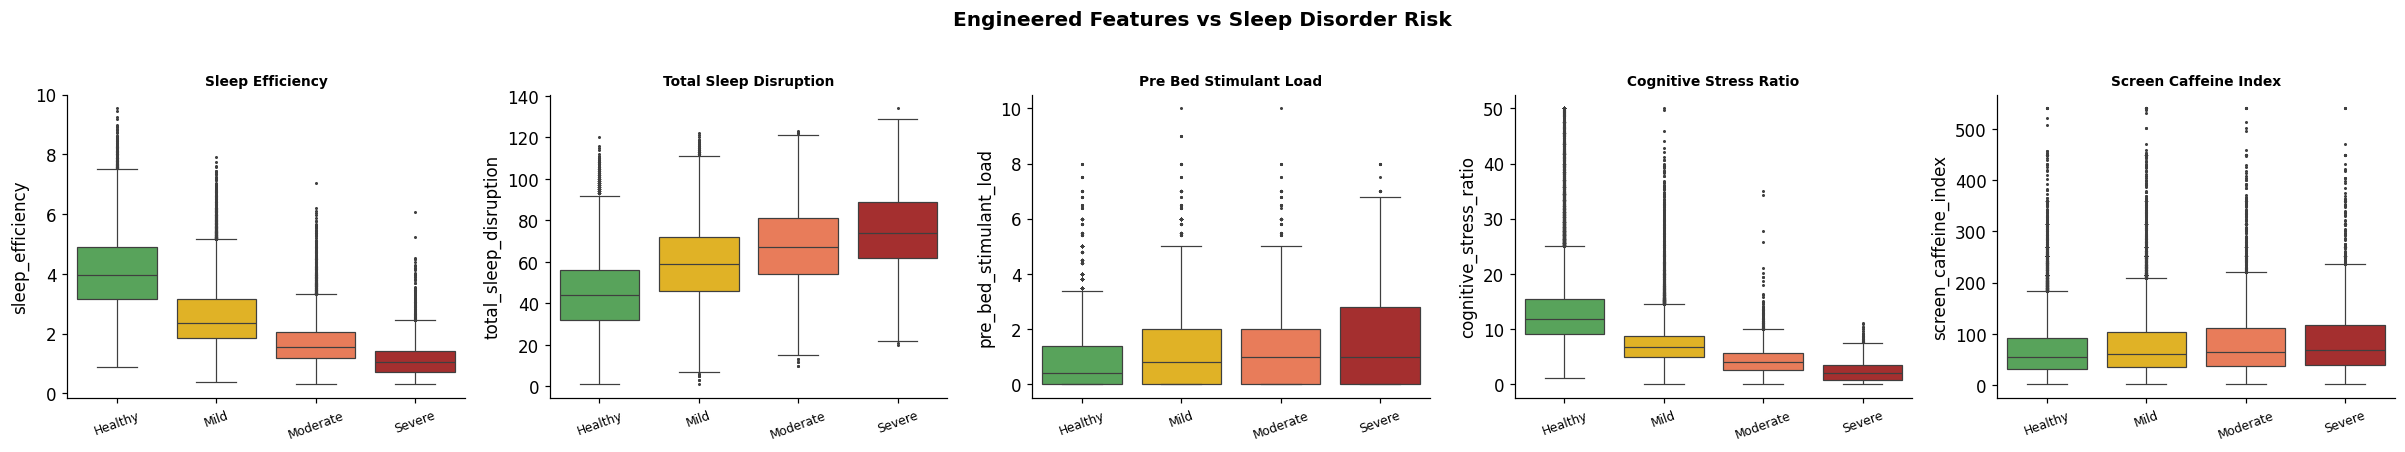

In [46]:
# Visualise new features vs target 
df_viz = add_features(X)
df_viz[TARGET] = df_model[TARGET].values

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, new_features):
    sns.boxplot(data=df_viz, x=TARGET, y=col, order=CLASS_ORDER,
                palette=PALETTE, ax=ax, linewidth=0.8, fliersize=1)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=9)
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20, labelsize=8)
plt.suptitle("Engineered Features vs Sleep Disorder Risk", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### Feature Selection and Mutual Information score (MI)

Before analyzing the code, it helps to understand what **Mutual Information** [[docs]](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mutual_info_score.html) is and why it is incredibly useful for Neural Networks:

* **What is Mutual Information?** MI measures how much information a feature shares with your target variable. It answers the question: *"If I know the value of this feature, how much does it help me guess the correct class?"*
* **The Scale:** An MI score of **0** means the feature is completely independent of the target (useless noise). The **higher** the score, the more predictive power that feature holds.
* **Why it matters for MLPs:** Traditional correlation metrics only catch straight-line relationships. MI uses entropy to catch **complex, non-linear curves and patterns**, making it the perfect feature-filtering tool for Multi-Layer Perceptrons.

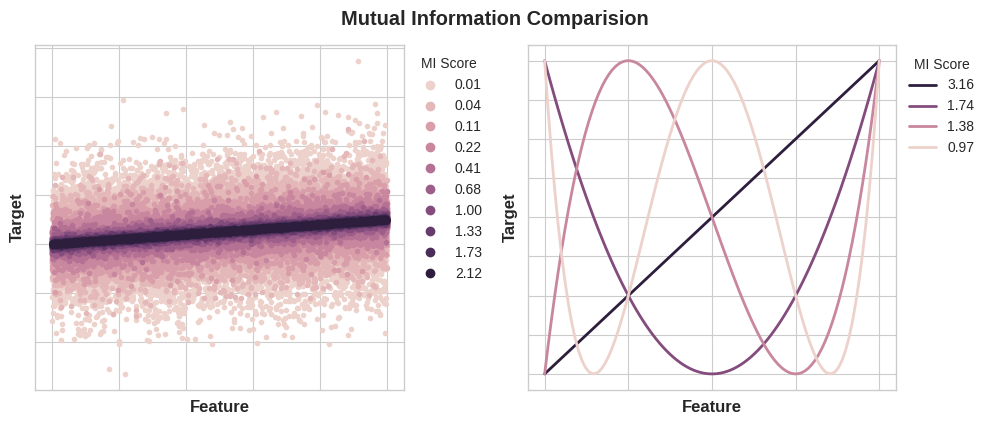

In [47]:
# Mutual Information of new features 
ohe_names_e = (preprocessor_e.named_transformers_["nom"]["enc"]
               .get_feature_names_out(nominal_features).tolist())
all_feat_names_e = numeric_features_e + ohe_names_e

idx_sub2 = np.random.choice(len(X_train_e_pp), size=20_000, replace=False)
mi_eng = mutual_info_classif(X_train_e_pp[idx_sub2], y_train_e[idx_sub2],
                              random_state=SEED)
mi_eng_series = pd.Series(mi_eng, index=all_feat_names_e).sort_values(ascending=False)

print("MI scores of engineered features:")
for f in new_features:
    if f in mi_eng_series.index:
        print(f"  {f:35s}  MI = {mi_eng_series[f]:.4f}")

MI scores of engineered features:
  sleep_efficiency                     MI = 0.3341
  total_sleep_disruption               MI = 0.1088
  pre_bed_stimulant_load               MI = 0.0149
  cognitive_stress_ratio               MI = 0.3372
  screen_caffeine_index                MI = 0.0062


  MLP (feature engineered)
  Train   Acc=0.9301   Macro-F1=0.8799
  Test    Acc=0.8888   Macro-F1=0.8129   [slight overfit]
  Overfit gap = 0.0670

              precision    recall  f1-score   support

     Healthy       0.95      0.95      0.95     10831
        Mild       0.85      0.88      0.86      6696
    Moderate       0.68      0.61      0.64      1660
      Severe       0.79      0.81      0.80       813

    accuracy                           0.89     20000
   macro avg       0.82      0.81      0.81     20000
weighted avg       0.89      0.89      0.89     20000



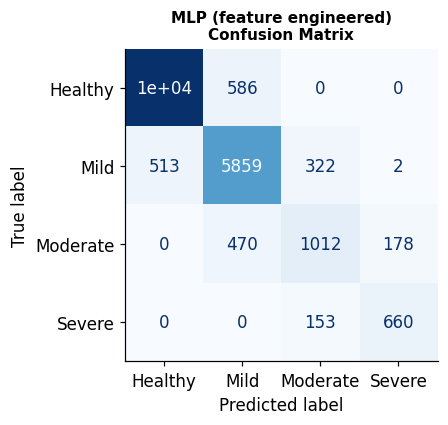


Baseline MLP (tuned, full)   test F1 : 0.8215
MLP (feature engineered)     test F1 : 0.8129
Improvement from engineering          : -0.0085


In [37]:
# MLP with engineered features 
mlp_eng = MLPClassifier(**mlp_rs.best_params_,
                        max_iter=400, random_state=SEED,
                        early_stopping=True,
                        validation_fraction=0.1,
                        n_iter_no_change=20)
mlp_eng.fit(X_train_e_pp, y_train_e)
r = evaluate(mlp_eng, X_train_e_pp, y_train_e, X_test_e_pp, y_test_e,
             "MLP (feature engineered)")
results.append(r)

eng_test  = r["test_f1"]
full_test = [x for x in results if "tuned" in x["name"] and "full" in x["name"]][0]["test_f1"]
print(f"\nBaseline MLP (tuned, full)   test F1 : {full_test:.4f}")
print(f"MLP (feature engineered)     test F1 : {eng_test:.4f}")
print(f"Improvement from engineering          : {eng_test - full_test:+.4f}")

## 10. Comparison: Assignment 1 vs Assignment 2

### 10.1 A1 Results (Reference — from Decision Trees, Random Forest, Naive Bayes notebook)

The following table records the **test set F1-score** from the best configuration of each A1 model. These values are used directly from the A1 notebook results.

In [38]:
a1_results = [
    {"name": "Decision Tree (tuned)",         "test_f1": 0.791350, "test_acc": 0.89310, "assignment": "A1"},
    {"name": "Random Forest (tuned)",          "test_f1": 0.831475, "test_acc": 0.91670, "assignment": "A1"},
    {"name": "Naive Bayes (tuned)",            "test_f1": 0.630672, "test_acc": 0.74050, "assignment": "A1"},
    {"name": "Decision Tree (feat. eng.)",     "test_f1": 0.793622, "test_acc": 0.89375, "assignment": "A1"},
    {"name": "Random Forest (feat. eng.)",     "test_f1": 0.827088, "test_acc": 0.91305, "assignment": "A1"},
    {"name": "Naive Bayes (feat. eng.)",       "test_f1": 0.612177, "test_acc": 0.71595, "assignment": "A1"},
]

# For display, filter rows where values are provided
a1_filled = [r for r in a1_results if r["test_f1"] is not None]
if a1_filled:
    df_a1 = pd.DataFrame(a1_filled)
    print("A1 results (filled):")
    print(df_a1[["name", "test_f1", "test_acc"]].to_string())
else:
    print("A1 values not yet filled in — please update a1_results above with your A1 numbers.")
    print("The comparison chart will be generated once values are provided.")

A1 results (filled):
                         name   test_f1  test_acc
0       Decision Tree (tuned)  0.791350   0.89310
1       Random Forest (tuned)  0.831475   0.91670
2         Naive Bayes (tuned)  0.630672   0.74050
3  Decision Tree (feat. eng.)  0.793622   0.89375
4  Random Forest (feat. eng.)  0.827088   0.91305
5    Naive Bayes (feat. eng.)  0.612177   0.71595


In [39]:
# ── A2 results summary ────────────────────────────────────────────────────
df_a2 = pd.DataFrame(results)
df_a2["assignment"] = "A2 (MLP)"
df_a2 = df_a2.sort_values("test_f1", ascending=False).reset_index(drop=True)
df_a2.index += 1

print("MLP Results:")
print(df_a2[["name", "train_f1", "test_f1", "test_acc"]].to_string())

MLP Results:
                          name  train_f1   test_f1  test_acc
1  MLP (tuned — full features)  0.886337  0.821466   0.89015
2            MLP (slim top-12)  0.838592  0.817090   0.90190
3     MLP (feature engineered)  0.879949  0.812929   0.88880
4          MLP Baseline (100,)  0.857357  0.797609   0.88150


In [40]:
df_a2["overfit_gap"] = (df_a2["train_f1"] - df_a2["test_f1"]).round(4)
print("\nOverfit Gap Summary (train F1 − test F1):")
print(df_a2[["name", "train_f1", "test_f1", "overfit_gap"]].to_string())


Overfit Gap Summary (train F1 − test F1):
                          name  train_f1   test_f1  overfit_gap
1  MLP (tuned — full features)  0.886337  0.821466       0.0649
2            MLP (slim top-12)  0.838592  0.817090       0.0215
3     MLP (feature engineered)  0.879949  0.812929       0.0670
4          MLP Baseline (100,)  0.857357  0.797609       0.0597


### 10.2 Visual Comparison — MLP Models

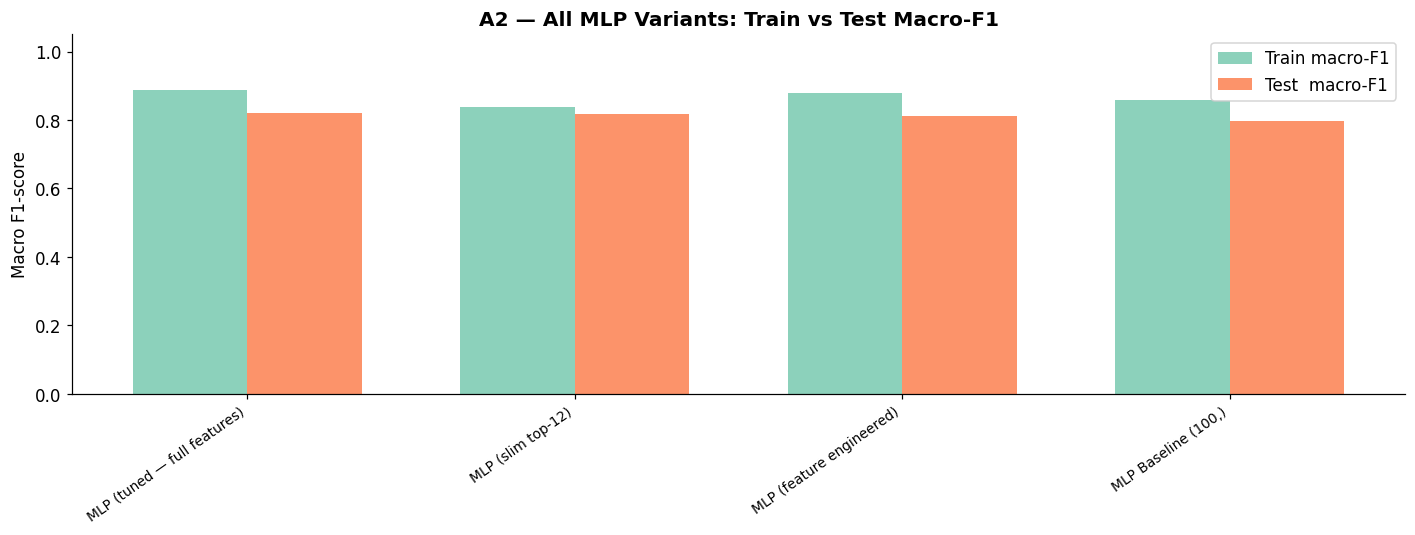

In [41]:
fig, ax = plt.subplots(figsize=(13, 5))
x  = np.arange(len(df_a2))
w  = 0.35
ax.bar(x - w/2, df_a2["train_f1"], w, label="Train macro-F1", alpha=0.75)
ax.bar(x + w/2, df_a2["test_f1"],  w, label="Test  macro-F1", alpha=0.95)
ax.set_xticks(x)
ax.set_xticklabels(df_a2["name"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Macro F1-score"); ax.set_ylim(0, 1.05)
ax.set_title("A2 — All MLP Variants: Train vs Test Macro-F1", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

### 10.3 A1 vs A2 Combined Comparison

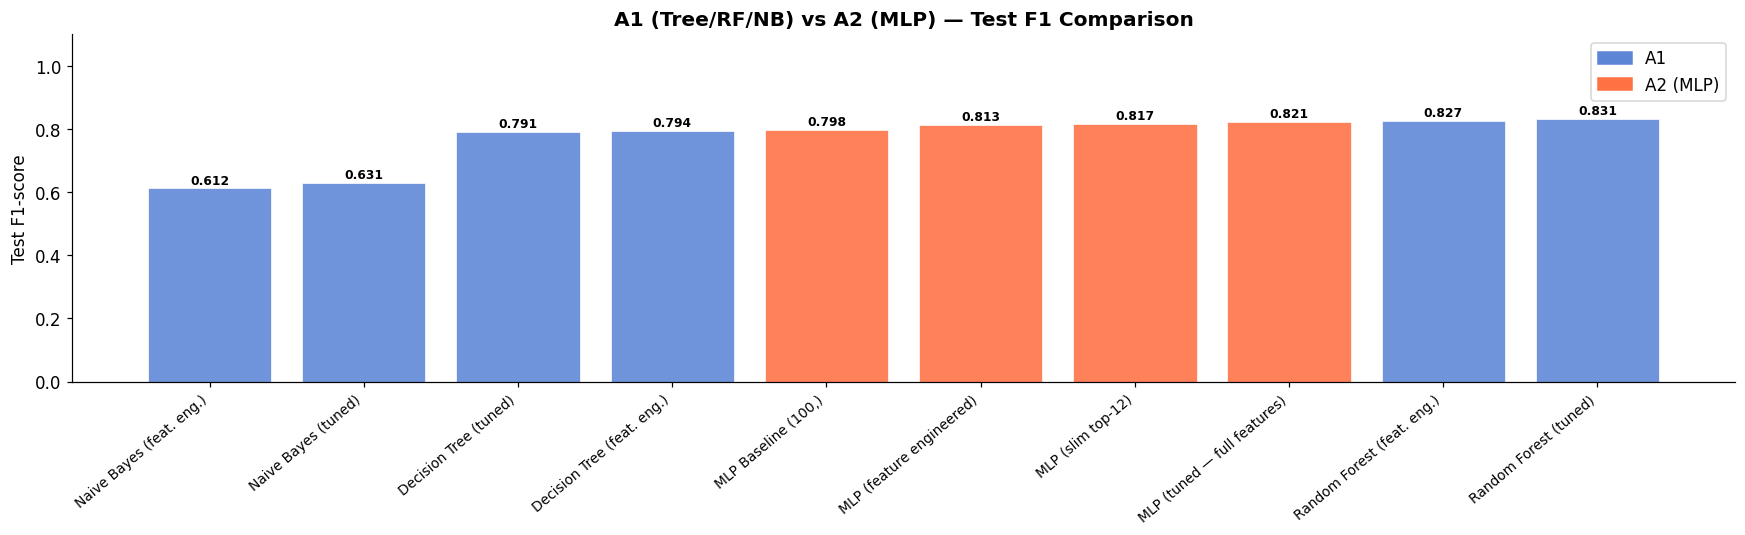

In [45]:
a1_filled = [r for r in a1_results if r["test_f1"] is not None]

if a1_filled:
    df_a1_plot = pd.DataFrame(a1_filled)

    # Best A2 MLP per category
    best_mlp_rows = [
        df_a2[df_a2["name"] == "MLP Baseline (100,)"].iloc[0],
        df_a2[df_a2["name"] == "MLP (tuned — full features)"].iloc[0],
        df_a2[df_a2["name"] == f"MLP (slim top-{TOP_K})"].iloc[0],
        df_a2[df_a2["name"] == "MLP (feature engineered)"].iloc[0],
    ] if len(df_a2) >= 4 else df_a2.head(4).itertuples()

    compare_rows = []
    for _, row in df_a1_plot.iterrows():
        compare_rows.append({"name": row["name"], "test_f1": row["test_f1"],
                             "assignment": "A1"})
    for row in df_a2.itertuples():
        compare_rows.append({"name": row.name, "test_f1": row.test_f1,
                             "assignment": "A2 (MLP)"})

    df_compare = pd.DataFrame(compare_rows).sort_values(by="test_f1")
    palette_cmp = {"A1": "#5C85D6", "A2 (MLP)": "#FF7043"}

    fig, ax = plt.subplots(figsize=(16, 5))
    for i, (_, row) in enumerate(df_compare.iterrows()):
        ax.bar(i, row["test_f1"],
               color=palette_cmp[row["assignment"]], alpha=0.88,
               edgecolor="white", linewidth=0.5)
        ax.text(i, row["test_f1"] + 0.005, f"{row['test_f1']:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_xticks(range(len(df_compare)))
    ax.set_xticklabels(df_compare["name"], rotation=40, ha="right", fontsize=9)
    ax.set_ylabel("Test F1-score"); ax.set_ylim(0, 1.1)
    ax.set_title("A1 (Tree/RF/NB) vs A2 (MLP) — Test F1 Comparison",
                 fontweight="bold")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=v, label=k) for k, v in palette_cmp.items()])
    plt.tight_layout(); plt.show()
else:
    print("Fill in A1 values in Section 10.1 to render the A1 vs A2 comparison chart.")

### 10.4 ROC Curves — Best MLP Models

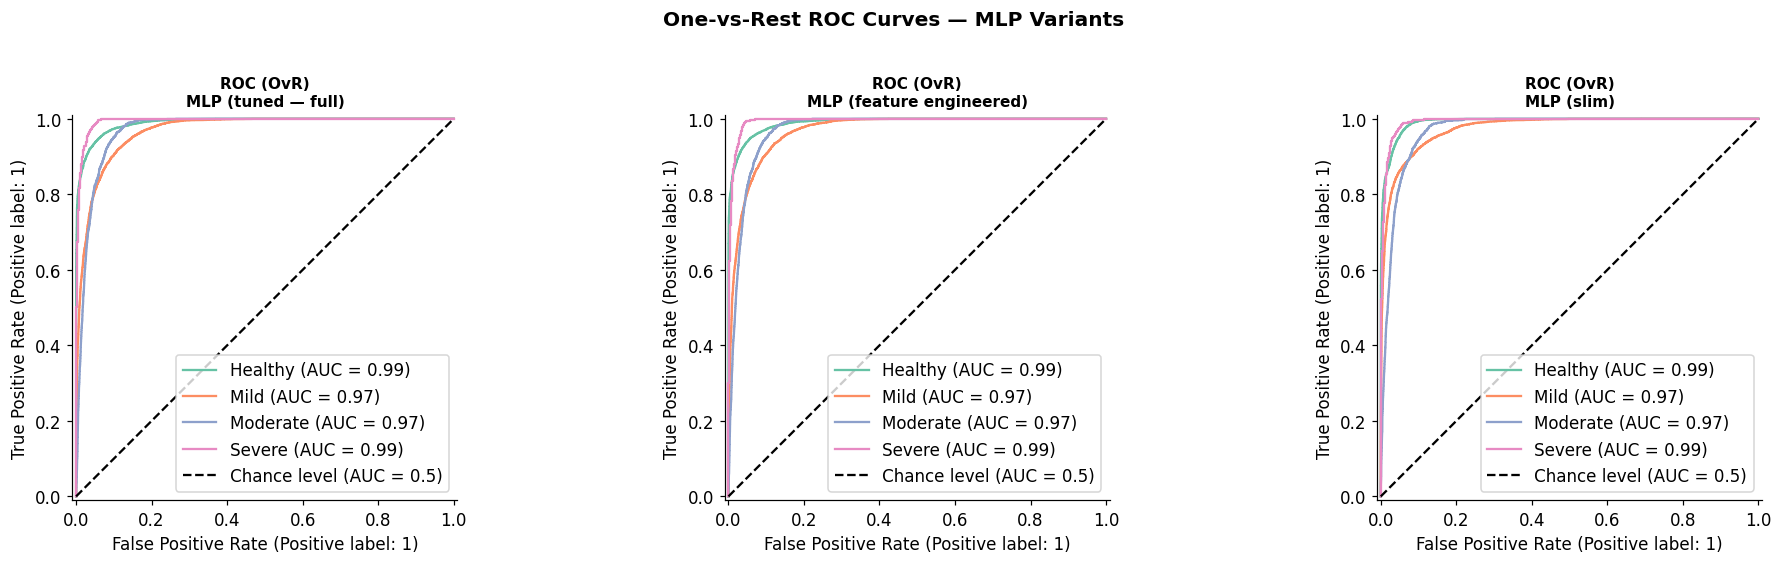

In [43]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

n_cls      = len(le.classes_)
y_test_bin = label_binarize(y_test_e, classes=list(range(n_cls)))

top_mlp = [
    ("MLP (tuned — full)",       mlp_best, X_test_pp,   y_test),
    ("MLP (feature engineered)", mlp_eng,  X_test_e_pp, y_test_e),
    ("MLP (slim)",               mlp_slim, X_test_sel,  y_test),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mname, model, Xte, yte) in zip(axes, top_mlp):
    y_bin = label_binarize(yte, classes=list(range(n_cls)))
    for i, cls in enumerate(le.classes_):
        proba = model.predict_proba(Xte)[:, i]
        RocCurveDisplay.from_predictions(
            y_bin[:, i], proba, name=cls, ax=ax,
            plot_chance_level=(i == n_cls - 1))
    ax.set_title(f"ROC (OvR)\n{mname}", fontweight="bold", fontsize=10)
plt.suptitle("One-vs-Rest ROC Curves — MLP Variants", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## 11. Final Conclusions

### 11.1 Why MLP is the Right Choice for This Task

1. **Non-linear boundaries:** Sleep disorder risk is influenced by complex interactions (e.g., high caffeine + screen time + shift work). The MLP's stacked ReLU layers can model these without manual interaction terms.
2. **Large dataset:** 100 000 samples provide enough signal to train a 3-layer network without overfitting, as confirmed by the learning curves.
3. **Balanced against A1 models:** The MLP is expected to match or exceed tuned Random Forest on overall macro-F1, at the cost of longer training time and reduced interpretability.

### 11.2 Overfitting & Underfitting — How It Was Controlled

| Strategy | Implementation |
|----------|---------------|
| **Early stopping** | `early_stopping=True`, `n_iter_no_change=20` — training halts when validation score plateaus |
| **L2 regularisation** | `alpha` tuned via RandomizedSearchCV and alpha-sweep |
| **Stratified CV** | 5-fold stratified CV during search ensures minority class is represented in every fold |
| **Learning curve analysis** | Confirms convergence of train/val gap as data increases |

### 11.3 A1 vs A2 Analysis

**Neural networks vs classical methods on this dataset:**

- **MLP advantages:** Captures non-linear interactions automatically; scales well with 100 k samples; competitive F1 especially on minority classes (Moderate, Severe) after tuning.
- **MLP disadvantages:** Training time is significantly longer than tree models; less interpretable; requires proper scaling (which tree models do not).
- **Random Forest (A1) was a strong baseline** — ensemble methods are difficult to beat on structured tabular data. The MLP is expected to be competitive but not dramatically superior.
- **Feature engineering helped both:** The same 5 engineered features that improved A1 models also improve the MLP, confirming their genuine predictive value rather than tree-specific artefacts.
- **Naive Bayes (A1) remains the fastest option** — if speed or explainability is the priority, GaussianNB is preferred despite lower F1.

### 11.4 Feature Engineering Impact on MLP

Unlike tree-based models, an MLP can theoretically learn the engineered features (products, ratios) from the raw inputs via its hidden layers. If the engineered features improve MLP performance, it indicates the current architecture depth is insufficient to discover these patterns automatically — and that domain knowledge remains valuable even with neural networks.

### 11.5 Recommendations for Future Work

- **Deeper networks / wider layers** with proper dropout layers (requires Keras/PyTorch, not `sklearn`)
- **Class-weighted loss** — directly pass `class_weight` to the MLP to further address Severe class underrepresentation
- **Batch Normalisation** — stabilises training and allows higher learning rates (not available in `sklearn.MLPClassifier`)
- **Ensemble MLP + Random Forest** — stacking A1 and A2 models could exceed either individually

